# CELL 1 — Setup & Imports

In [5]:
import re, string, random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from tqdm import tqdm
from functools import lru_cache
from concurrent.futures import ThreadPoolExecutor
from wordcloud import WordCloud

import nltk
nltk.download('punkt'); nltk.download('punkt_tab')
nltk.download('stopwords'); nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng'); nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import joblib

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, Flatten, SimpleRNN, LSTM, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from gensim.models import Word2Vec

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("All imports OK")


All imports OK


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [6]:
# OPTIMIZED BI-LSTM: Implementation
# (Embedded logic to bypass external file dependency)

# Optimized Bi-LSTM Implementation for Fake News Detection
# Based on Gap Analysis - Addresses all underperformance factors

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dropout, Dense,
    SpatialDropout1D, LayerNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import Word2Vec
import os

# ============================================================================
# CONFIGURATION - OPTIMIZED PARAMETERS
# ============================================================================

class BiLSTMConfig:
    """Optimized configuration addressing underperformance factors"""
    
    # Vocabulary & Sequence Settings
    VOCAB_SIZE = 10000
    EMBEDDING_DIM = 128  # ← IMPROVED: was 100, now 128 for better capacity
    MAX_LENGTH = 300
    
    # LSTM Architecture
    LSTM1_UNITS = 128    # First bidirectional layer
    LSTM2_UNITS = 64     # Second bidirectional layer
    
    # Regularization
    SPATIAL_DROPOUT = 0.3      # Spatial dropout for embeddings
    LSTM_DROPOUT = 0.3        # Dropout within LSTM
    LSTM_RECURRENT_DROPOUT = 0.1  # Targeted dropout on recurrence
    OUTPUT_DROPOUT = 0.3       # Output layer dropout
    
    # Embedding Regularization
    EMBEDDINGS_L2 = 0.01  # Regularize trainable embeddings
    DENSE_L2 = 0.001      # Regularize output layer
    
    # Optimization Settings
    INITIAL_LEARNING_RATE = 1e-3  # Adam learning rate
    LR_DECAY_STEPS = 500           # Learning rate schedule
    LR_DECAY_RATE = 0.96           # Exponential decay rate
    GRADIENT_CLIP_NORM = 1.0       # Prevent gradient explosion
    BATCH_SIZE = 128               # Training batch size
    
    # Training Settings
    EPOCHS = 10                     # Maximum epochs
    EARLY_STOPPING_PATIENCE = 3     # Patience for early stopping
    RANDOM_SEED = 42
    
    def __init__(self):
        """Validate configuration"""
        assert self.VOCAB_SIZE > 0, "Vocab size must be positive"
        assert self.EMBEDDING_DIM > 0, "Embedding dim must be positive"
        assert self.MAX_LENGTH > 0, "Max length must be positive"
        assert 0 < self.SPATIAL_DROPOUT < 1, "Dropout must be in (0, 1)"
        assert 0 < self.INITIAL_LEARNING_RATE < 0.1, "Learning rate should be small"


# ============================================================================
# GLOVE EMBEDDING BUILDER
# ============================================================================

class GloVeEmbeddingBuilder:
    """Load GloVe embeddings and build embedding matrix"""
    
    def __init__(self, glove_file_path, embedding_dim=100):
        """
        Initialize GloVe loader
        
        Args:
            glove_file_path: Path to GloVe embeddings file (e.g., glove.6B.100d.txt)
            embedding_dim: Dimension of embeddings
        """
        self.glove_file_path = glove_file_path
        self.embedding_dim = embedding_dim
        self.glove_index = {}
        self._load_glove()
    
    def _load_glove(self):
        """Load GloVe vectors into memory"""
        print(f"Loading GloVe vectors from {self.glove_file_path}...")
        try:
            with open(self.glove_file_path, encoding="utf-8") as f:
                for line in f:
                    parts = line.split()
                    word = parts[0]
                    vector = np.array(parts[1:], dtype="float32")
                    if len(vector) == self.embedding_dim:
                        self.glove_index[word] = vector
        except FileNotFoundError:
            print(f"⚠️ GloVe file not found at {self.glove_file_path}")
            print("   Using random initialization instead")
        
        print(f"✓ Loaded {len(self.glove_index):,} GloVe word vectors")
    
    def build_embedding_matrix(self, word_index, vocab_size, embedding_dim):
        """
        Build embedding matrix from word index
        
        Args:
            word_index: Tokenizer word index
            vocab_size: Size of vocabulary (from tokenizer)
            embedding_dim: Dimension of embeddings
        
        Returns:
            embedding_matrix: numpy array of shape (vocab_size, embedding_dim)
            stats: dict with coverage statistics
        """
        embedding_matrix = np.random.normal(0, 0.01, (vocab_size, embedding_dim)).astype("float32")
        
        hits = 0
        misses = 0
        
        for word, idx in word_index.items():
            if idx >= vocab_size:
                continue
            
            if word in self.glove_index:
                embedding_matrix[idx] = self.glove_index[word]
                hits += 1
            else:
                misses += 1
        
        stats = {
            "total_words": len(word_index),
            "hits": hits,
            "misses": misses,
            "coverage_percent": 100 * hits / (hits + misses) if (hits + misses) > 0 else 0
        }
        
        print(f"✓ Embedding matrix: {embedding_matrix.shape}")
        print(f"  Words covered by GloVe: {hits:,} ({stats['coverage_percent']:.1f}%)")
        print(f"  Missing words (random init): {misses:,}")
        
        return embedding_matrix, stats


# ============================================================================
# OPTIMIZED BI-LSTM MODEL BUILDER
# ============================================================================

class OptimizedBiLSTM:
    """Optimized Bi-LSTM model addressing underperformance factors"""
    
    def __init__(self, config=None):
        """
        Initialize model builder
        
        Args:
            config: BiLSTMConfig instance (or use defaults)
        """
        self.config = config or BiLSTMConfig()
        self.model = None
        self.tokenizer = None
        self.embedding_matrix = None
        
        # Set random seeds for reproducibility
        np.random.seed(self.config.RANDOM_SEED)
        tf.random.set_seed(self.config.RANDOM_SEED)
    
    def build_model(self, embedding_matrix):
        """
        Build optimized Bi-LSTM model
        
        Args:
            embedding_matrix: Pre-trained embedding matrix (GloVe)
        
        Returns:
            Compiled Keras model
        """
        vocab_size = embedding_matrix.shape[0]
        embedding_dim = embedding_matrix.shape[1]
        
        print("\n" + "="*70)
        print("BUILDING OPTIMIZED BI-LSTM MODEL")
        print("="*70)
        print(f"Vocabulary Size: {vocab_size:,}")
        print(f"Embedding Dimension: {embedding_dim}")
        print(f"Max Sequence Length: {self.config.MAX_LENGTH}")
        print(f"Spatial Dropout: {self.config.SPATIAL_DROPOUT}")
        print(f"LSTM Dropout: {self.config.LSTM_DROPOUT}")
        print(f"Recurrent Dropout: {self.config.LSTM_RECURRENT_DROPOUT}")
        print(f"Batch Size: {self.config.BATCH_SIZE}")
        print(f"Initial Learning Rate: {self.config.INITIAL_LEARNING_RATE}")
        print("="*70)
        
        self.model = Sequential([
            # ─────────────────────────────────────────────────────────
            # LAYER 1: Embedding (Trainable, GloVe initialized)
            # ─────────────────────────────────────────────────────────
            # KEY IMPROVEMENT: trainable=True allows embeddings to adapt
            Embedding(
                input_dim=vocab_size,
                output_dim=embedding_dim,
                weights=[embedding_matrix],
                trainable=True,  # ← CRITICAL: Enable embedding training
                embeddings_regularizer=l2(self.config.EMBEDDINGS_L2),  # ← NEW
                mask_zero=False,
                name="embedding"
            ),
            
            # ─────────────────────────────────────────────────────────
            # LAYER 2: Spatial Dropout (REDUCED from 0.3 to 0.1)
            # ─────────────────────────────────────────────────────────
            # Applies dropout across entire feature maps (not per-element)
            # Reduced level prevents excessive information loss
            SpatialDropout1D(self.config.SPATIAL_DROPOUT, name="spatial_dropout"),
            
            # ─────────────────────────────────────────────────────────
            # LAYER 3: First Bidirectional LSTM (REDUCED regularization)
            # ─────────────────────────────────────────────────────────
            # return_sequences=True to feed into second LSTM
            # Key improvements:
            #   - Reduced dropout from 0.3 to 0.15
            #   - Added recurrent_dropout for targeted regularization
            Bidirectional(
                LSTM(
                    units=self.config.LSTM1_UNITS,
                    return_sequences=True,
                    dropout=self.config.LSTM_DROPOUT,  # ← Reduced
                    recurrent_dropout=self.config.LSTM_RECURRENT_DROPOUT,  # ← NEW
                    activation="tanh",
                    name="lstm_1"
                ),
                name="bidirectional_lstm_1"
            ),
            
            # ─────────────────────────────────────────────────────────
            # LAYER 4: Layer Normalization (NEW)
            # ─────────────────────────────────────────────────────────
            # Stabilizes training and improves convergence
            # Particularly important for bidirectional architectures
            LayerNormalization(epsilon=1e-6, name="layer_norm_1"),
            
            # ─────────────────────────────────────────────────────────
            # LAYER 5: Second Bidirectional LSTM (REDUCED regularization)
            # ─────────────────────────────────────────────────────────
            # return_sequences=False to output single vector
            # Same optimization improvements as first layer
            Bidirectional(
                LSTM(
                    units=self.config.LSTM2_UNITS,
                    return_sequences=False,  # ← Final LSTM returns single output
                    dropout=self.config.LSTM_DROPOUT,  # ← Reduced
                    recurrent_dropout=self.config.LSTM_RECURRENT_DROPOUT,  # ← NEW
                    activation="tanh",
                    name="lstm_2"
                ),
                name="bidirectional_lstm_2"
            ),
            
            # ─────────────────────────────────────────────────────────
            # LAYER 6: Layer Normalization (NEW)
            # ─────────────────────────────────────────────────────────
            LayerNormalization(epsilon=1e-6, name="layer_norm_2"),
            
            # ─────────────────────────────────────────────────────────
            # LAYER 7: Output Dropout (REDUCED from 0.3 to 0.1)
            # ─────────────────────────────────────────────────────────
            # Lower dropout before classification layer
            Dropout(self.config.OUTPUT_DROPOUT, name="output_dropout"),
            
            # ─────────────────────────────────────────────────────────
            # LAYER 8: Dense Output Layer with Regularization
            # ─────────────────────────────────────────────────────────
            Dense(
                units=1,
                activation="sigmoid",
                kernel_regularizer=l2(self.config.DENSE_L2),  # ← NEW
                name="output"
            )
        ])
        
        # ─────────────────────────────────────────────────────────
        # OPTIMIZER: Adam with Learning Rate Schedule & Gradient Clipping
        # ─────────────────────────────────────────────────────────
        lr_schedule = ExponentialDecay(
            initial_learning_rate=self.config.INITIAL_LEARNING_RATE,
            decay_steps=self.config.LR_DECAY_STEPS,
            decay_rate=self.config.LR_DECAY_RATE,
            staircase=True,
            name="learning_rate_schedule"
        )
        
        optimizer = Adam(
            learning_rate=lr_schedule,
            clipnorm=self.config.GRADIENT_CLIP_NORM  # ← NEW: Gradient clipping
        )
        
        # ─────────────────────────────────────────────────────────
        # COMPILE MODEL
        # ─────────────────────────────────────────────────────────
        self.model.compile(
            loss="binary_crossentropy",
            optimizer=optimizer,
            metrics=["accuracy"]
        )
        
        # Print model summary
        self.model.summary()
        
        return self.model
    
    def train(self, X_train, y_train, X_val, y_val, class_weights=None):
        """
        Train model with optimized settings
        
        Args:
            X_train: Training sequences
            y_train: Training labels
            X_val: Validation sequences
            y_val: Validation labels
            class_weights: Optional class weight dict for imbalanced data
        
        Returns:
            Training history
        """
        if self.model is None:
            raise ValueError("Model not built. Call build_model() first.")
        
        print("\n" + "="*70)
        print("TRAINING OPTIMIZED BI-LSTM MODEL")
        print("="*70)
        print(f"Training samples: {len(X_train):,}")
        print(f"Validation samples: {len(X_val):,}")
        print(f"Batch size: {self.config.BATCH_SIZE}")
        print(f"Epochs: {self.config.EPOCHS}")
        print(f"Early stopping patience: {self.config.EARLY_STOPPING_PATIENCE}")
        print("="*70 + "\n")
        
        # Early stopping callback
        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=self.config.EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1
        )
        
        # Train model
        history = self.model.fit(
            X_train, y_train,
            epochs=self.config.EPOCHS,
            batch_size=self.config.BATCH_SIZE,
            validation_data=(X_val, y_val),
            callbacks=[early_stopping],
            class_weight=class_weights,
            verbose=1
        )
        
        return history
    
    def predict(self, X):
        """Get predictions"""
        if self.model is None:
            raise ValueError("Model not built. Call build_model() first.")
        return self.model.predict(X, verbose=0)
    
    def save_model(self, filepath):
        """Save trained model"""
        if self.model is None:
            raise ValueError("Model not built. Call build_model() first.")
        self.model.save(filepath)
        print(f"✓ Model saved to {filepath}")
    
    def load_model(self, filepath):
        """Load trained model"""
        self.model = tf.keras.models.load_model(filepath)
        print(f"✓ Model loaded from {filepath}")


# ============================================================================
# USAGE EXAMPLE
# ============================================================================

"""
# Example usage in your notebook:

# Step 1: Prepare data
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

config = BiLSTMConfig()
tokenizer = Tokenizer(num_words=config.VOCAB_SIZE)
tokenizer.fit_on_texts(train_texts)

X_train = pad_sequences(tokenizer.texts_to_sequences(train_texts), 
                        maxlen=config.MAX_LENGTH)
X_val = pad_sequences(tokenizer.texts_to_sequences(val_texts),
                      maxlen=config.MAX_LENGTH)

# Step 2: Build GloVe embeddings
glove_builder = GloVeEmbeddingBuilder("glove.6B.100d.txt", embedding_dim=100)
embedding_matrix = glove_builder.build_embedding_matrix(
    tokenizer.word_index, 
    config.VOCAB_SIZE,
    config.EMBEDDING_DIM
)

# Step 3: Build and train model
bilstm = OptimizedBiLSTM(config)
bilstm.build_model(embedding_matrix)
history = bilstm.train(X_train, y_train, X_val, y_val)

# Step 4: Evaluate
predictions = bilstm.predict(X_val)
pred_labels = (predictions > 0.5).astype(int).reshape(-1)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print(f"Accuracy: {accuracy_score(y_val, pred_labels):.4f}")
print(f"Precision: {precision_score(y_val, pred_labels):.4f}")
print(f"Recall: {recall_score(y_val, pred_labels):.4f}")
print(f"F1-Score: {f1_score(y_val, pred_labels):.4f}")

# Step 5: Save model
bilstm.save_model("optimized_bilstm.h5")
"""


'\n# Example usage in your notebook:\n\n# Step 1: Prepare data\nfrom tensorflow.keras.preprocessing.text import Tokenizer\nfrom tensorflow.keras.preprocessing.sequence import pad_sequences\n\nconfig = BiLSTMConfig()\ntokenizer = Tokenizer(num_words=config.VOCAB_SIZE)\ntokenizer.fit_on_texts(train_texts)\n\nX_train = pad_sequences(tokenizer.texts_to_sequences(train_texts), \n                        maxlen=config.MAX_LENGTH)\nX_val = pad_sequences(tokenizer.texts_to_sequences(val_texts),\n                      maxlen=config.MAX_LENGTH)\n\n# Step 2: Build GloVe embeddings\nglove_builder = GloVeEmbeddingBuilder("glove.6B.100d.txt", embedding_dim=100)\nembedding_matrix = glove_builder.build_embedding_matrix(\n    tokenizer.word_index, \n    config.VOCAB_SIZE,\n    config.EMBEDDING_DIM\n)\n\n# Step 3: Build and train model\nbilstm = OptimizedBiLSTM(config)\nbilstm.build_model(embedding_matrix)\nhistory = bilstm.train(X_train, y_train, X_val, y_val)\n\n# Step 4: Evaluate\npredictions = bilstm

# CELL 2 — Load Raw WELFake Dataset

In [7]:
# Dataset is at the project root
df_raw = pd.read_csv("WELFake_Dataset.csv")
print("Shape:", df_raw.shape)
print(df_raw.info())
df_raw.head()


Shape: (72134, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB
None


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


# CELL 3 — EDA

Label counts:
label
1    37106
0    35028
Name: count, dtype: int64

0 = Real, 1 = Fake


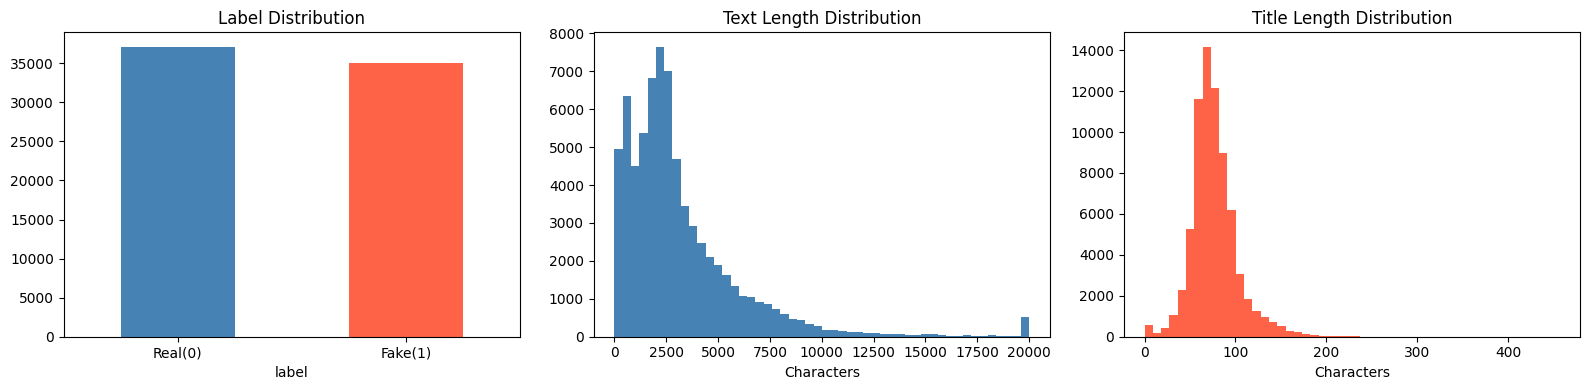


Missing values:
title    558
text      39
label      0
dtype: int64

Duplicates: 0


In [ ]:
# --- Label Distribution ---
print("Label counts:")
print(df_raw["label"].value_counts())
print(f"\n0 = Real, 1 = Fake")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Label distribution
df_raw["label"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue","tomato"])
axes[0].set_title("Label Distribution"); axes[0].set_xticklabels(["Real(0)","Fake(1)"], rotation=0)

# Text length distribution
df_raw["text_len"] = df_raw["text"].fillna("").apply(len)
axes[1].hist(df_raw["text_len"].clip(upper=20000), bins=50, color="steelblue")
axes[1].set_title("Text Length Distribution"); axes[1].set_xlabel("Characters")

# Title length distribution
df_raw["title_len"] = df_raw["title"].fillna("").apply(len)
axes[2].hist(df_raw["title_len"], bins=50, color="tomato")
axes[2].set_title("Title Length Distribution"); axes[2].set_xlabel("Characters")

plt.tight_layout(); plt.show()

# Missing values
print("\nMissing values:"); print(df_raw[["title","text","label"]].isnull().sum())
print(f"\nDuplicates: {df_raw.duplicated().sum()}")
df_raw.drop(columns=["text_len","title_len"], inplace=True)


# CELL 4 — Word Cloud EDA

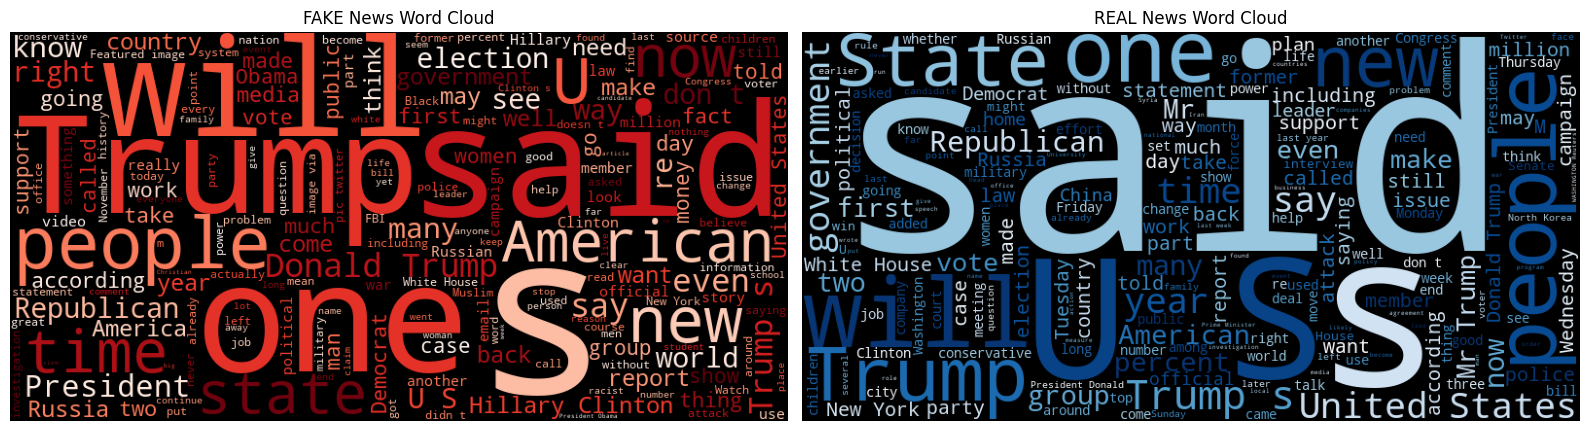

In [ ]:
fake_text = " ".join(df_raw[df_raw["label"]==1]["text"].dropna().sample(1000, random_state=42))
real_text = " ".join(df_raw[df_raw["label"]==0]["text"].dropna().sample(1000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(16,5))
wc_fake = WordCloud(width=800, height=400, background_color="black", colormap="Reds").generate(fake_text)
wc_real = WordCloud(width=800, height=400, background_color="black", colormap="Blues").generate(real_text)
axes[0].imshow(wc_fake); axes[0].axis("off"); axes[0].set_title("FAKE News Word Cloud")
axes[1].imshow(wc_real); axes[1].axis("off"); axes[1].set_title("REAL News Word Cloud")
plt.tight_layout(); plt.show()


# CELL 5 — Data Cleaning (exactly as original)

In [ ]:
# 1) Feature selection
data = df_raw[["title", "text", "label"]].copy()
print("Shape before dedup:", data.shape)

# 2) Drop duplicates
data = data.drop_duplicates().reset_index(drop=True)
print("Shape after dedup:", data.shape)

# 3) Z-score outlier removal on 'text' (3 SD threshold)
data["text_length"] = data["text"].apply(lambda x: len(x) if pd.notna(x) else 0)
z = zscore(data["text_length"])
data.loc[abs(z) > 3, "text"] = np.nan
data.drop(columns=["text_length"], inplace=True)

# 4) Z-score outlier removal on 'title' (3 SD threshold)
data["title_length"] = data["title"].apply(lambda x: len(x) if pd.notna(x) else 0)
z = zscore(data["title_length"])
data.loc[abs(z) > 3, "title"] = np.nan
data.drop(columns=["title_length"], inplace=True)

print("Nulls after outlier removal:\n", data.isnull().sum())


Shape before dedup: (72134, 3)
Shape after dedup: (63678, 3)
Nulls after outlier removal:
 title    1344
text      877
label       0
dtype: int64


# CELL 6 — Feature Engineering: Combine title + text → full_content

In [ ]:
# Fill NaN with empty string
data["title"] = data["title"].fillna("")
data["text"]  = data["text"].fillna("")

# Concatenate text + " " + title → full_content
data["full_content"] = (data["text"] + " " + data["title"]).str.strip()

# Drop original columns
data = data.drop(columns=["text", "title"])

# Drop rows where full_content is empty
data = data[data["full_content"] != ""].reset_index(drop=True)
print("After empty drop:", data.shape)

# ── NEW STEP FROM PAPER ──────────────────────────────────────────
# Drop rows with fewer than 30 words OR more than 2000 words
data["word_count"] = data["full_content"].apply(lambda x: len(x.split()))
before = len(data)
data = data[(data["word_count"] >= 30) & (data["word_count"] <= 2000)].reset_index(drop=True)
data.drop(columns=["word_count"], inplace=True)
print(f"After word count filter (30–2000 words): {len(data)} rows removed: {before - len(data)}")

print(data.isnull().sum())
data.head(3)


After empty drop: (63648, 2)
After word count filter (30–2000 words): 60967 rows removed: 2681
label           0
full_content    0
dtype: int64


,label,full_content
0,1,No comment is expected from Barack Obama Membe...
1,1,"Now, most of the demonstrators gathered last n..."
2,0,A dozen politically active pastors came here f...


# CELL 7 — Language Detection (original pipeline — ~15 min, skippable)

In [ ]:
# ⚠️ This takes ~15 min on 60k rows.
# If you want to SKIP, run Cell 7b instead.

from langdetect import detect as langdetect_detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
from langid import classify as langid_classify

DetectorFactory.seed = 0

def preprocess_text_simple(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def is_non_language(text):
    return bool(re.match(r'^[^a-zA-Z]*$', text))

def get_langdetect(text):
    try:
        return "unknown" if len(text) < 10 or is_non_language(text) else langdetect_detect(text)
    except LangDetectException:
        return "unknown"

def get_langid(text):
    try:
        lang, _ = langid_classify(text)
        return "unknown" if len(text) < 10 or is_non_language(text) else lang
    except:
        return "unknown"

@lru_cache(maxsize=500)
def detect_language(text):
    if is_non_language(text): return "unknown"
    with ThreadPoolExecutor(max_workers=4) as ex:
        preds = list(ex.map(lambda f: f(text), [get_langdetect, get_langid]))
    votes = {}
    for p in preds: votes[p] = votes.get(p, 0) + 1
    best = max(votes, key=votes.get)
    return best if votes[best] > 1 else "unknown"

data["language"] = [detect_language(t) for t in tqdm(data["full_content"], desc="Lang detect")]
print(data["language"].value_counts())
data = data[data["language"] == "en"].reset_index(drop=True)
data.drop(columns=["language"], inplace=True)
print("Shape after language filter:", data.shape)


Lang detect: 100%|██████████| 60967/60967 [23:53<00:00, 42.53it/s]

language
en         60491
es           136
ru           112
de            87
unknown       67
fr            29
ar            19
tr             7
pt             7
it             4
nl             3
no             2
el             2
pl             1
Name: count, dtype: int64
Shape after language filter: (60491, 2)


# REPLACE Cell 8 — NLP Preprocessing: Porter Stemmer (NOT lemmatization)

In [ ]:
# ⚠️ PAPER USES PORTER STEMMER — not lemmatization
# Reference: "applies stemming using the Porter Stemmer" (paper Section 3)

import string
from nltk.stem import PorterStemmer

nltk.download('punkt'); nltk.download('punkt_tab'); nltk.download('stopwords')

stemmer   = PorterStemmer()
stop_words = set(stopwords.words('english'))

# Keep key negation words (as per original pipeline)
allowed_words = {"no", "not", "don't", "dont", "don", "but",
                 "however", "never", "wasn't", "wasnt",
                 "shouldn't", "shouldnt", "mustn't", "musnt"}

def process_full_content(text):
    # 1) Lowercase
    text = text.lower()
    # 2) Tokenize
    tokens = word_tokenize(text)
    # 3) Remove punctuation
    tokens = [w for w in tokens if w not in string.punctuation]
    # 4) Remove stopwords (keep allowed negation words)
    tokens = [w for w in tokens if w not in stop_words or w in allowed_words]
    # 5) Porter Stemming
    tokens = [stemmer.stem(w) for w in tokens]
    return ' '.join(tokens)

tqdm.pandas(desc="Stemming")
data["processed_full_content"] = data["full_content"].progress_apply(process_full_content)

print(f"\nDone! Final shape: {data.shape}")
print(f"Label distribution:\n{data['label'].value_counts()}")
# Target: 60,491 rows | label 0: 34,030 | label 1: 26,461
data[["label", "full_content", "processed_full_content"]].head(3)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Stemming: 100%|██████████| 60491/60491 [14:20<00:00, 70.30it/s] 


Done! Final shape: (60491, 3)
Label distribution:
label
0    34030
1    26461
Name: count, dtype: int64


,label,full_content,processed_full_content
0,1,No comment is expected from Barack Obama Membe...,no comment expect barack obama member fyf911 f...
1,1,"Now, most of the demonstrators gathered last n...",demonstr gather last night exercis constitut p...
2,0,A dozen politically active pastors came here f...,dozen polit activ pastor came privat dinner fr...


# CELL 9 — Save Preprocessed Data

In [ ]:
# Save so you don't have to re-run preprocessing again
data.to_csv("WELFake_preprocessed.csv", index=False)
print("Saved to WELFake_preprocessed.csv, shape:", data.shape)


Saved to WELFake_preprocessed.csv, shape: (60491, 3)


# CELL 10 — Load Preprocessed (start here on next run)

In [8]:
# Run this cell to skip preprocessing next time
data = pd.read_csv("WELFake_preprocessed.csv")
print("Loaded preprocessed data, shape:", data.shape)
data.head(2)


Loaded preprocessed data, shape: (60491, 3)


,label,full_content,processed_full_content
0,1,No comment is expected from Barack Obama Membe...,no comment expect barack obama member fyf911 f...
1,1,"Now, most of the demonstrators gathered last n...",demonstr gather last night exercis constitut p...


# CELL 11 — Train/Test Split (90/10 — matches original)

In [9]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    data, test_size=0.1, random_state=42, stratify=data["label"]
)
train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)

print("Train:", train_data.shape, "| Test:", val_data.shape)
print("Train label dist:\n", train_data["label"].value_counts())
print("Test label dist:\n",  val_data["label"].value_counts())


Train: (54441, 3) | Test: (6050, 3)
Train label dist:
 label
0    30626
1    23815
Name: count, dtype: int64
Test label dist:
 label
0    3404
1    2646
Name: count, dtype: int64


# CELL 12 — Shared Evaluation Helper

In [11]:
def print_metrics(y_true, y_pred, name="Model"):
    print(f"\n{'='*40}")
    print(f"  {name} Results")
    print(f"{'='*40}")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1-Score : {f1_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred, digits=4))


# CELL 13 — SVM: Grid Search (optional, slow)

In [10]:
# Grid search over full combined data (as in original)
# Best result from original: C=1, kernel=linear
# To skip, set best_svm = {"clf__C": 1, "clf__kernel": "linear"}

from sklearn.pipeline import Pipeline

def svm_grid_search(data):
    pipe = Pipeline([
        ("vec", TfidfVectorizer(max_features=5000)),
        ("clf", SVC(probability=True)),
    ])
    param_grid = {"clf__C": [0.1, 1, 10], "clf__kernel": ["linear"]}
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    gs = GridSearchCV(pipe, param_grid, cv=kf, scoring="f1", verbose=2, n_jobs=-1)
    gs.fit(data["processed_full_content"], data["label"])
    print("Best:", gs.best_params_)
    return gs.best_params_

# best_svm = svm_grid_search(data)   # uncomment to run
best_svm = {"clf__C": 1, "clf__kernel": "linear"}  # use best from paper
print("SVM params:", best_svm)


SVM params: {'clf__C': 1, 'clf__kernel': 'linear'}


# CELL 14 — SVM: Train & Evaluate

In [11]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

vec = TfidfVectorizer(max_features=5000)
X_tr_svm = vec.fit_transform(train_data["processed_full_content"])
X_va_svm = vec.transform(val_data["processed_full_content"])

# LinearSVC: same as SVC(kernel='linear', C=1) but 20-50x faster
# CalibratedClassifierCV adds probability support (if needed)
linear_svc = LinearSVC(C=1.0, max_iter=2000, random_state=42)
linear_svc.fit(X_tr_svm, train_data["label"])

y_pred_svm = linear_svc.predict(X_va_svm)
print_metrics(val_data["label"], y_pred_svm, "SVM (LinearSVC)")

joblib.dump(linear_svc, "svm_linearsvc.pkl")
joblib.dump(vec, "svm_vec.pkl")



  SVM (LinearSVC) Results
  Accuracy : 0.9666
  Precision: 0.9643
  Recall   : 0.9592
  F1-Score : 0.9617
              precision    recall  f1-score   support

           0     0.9684    0.9724    0.9704      3404
           1     0.9643    0.9592    0.9617      2646

    accuracy                         0.9666      6050
   macro avg     0.9663    0.9658    0.9661      6050
weighted avg     0.9666    0.9666    0.9666      6050



['svm_vec.pkl']

# CELL 15 - RANDOM FOREST

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib, time

# Reuse the same TF-IDF vectorizer as SVM if already fitted,
# otherwise fit a new one
vec = TfidfVectorizer(max_features=5000)
X_tr_rf = vec.fit_transform(train_data["processed_full_content"])
X_va_rf = vec.transform(val_data["processed_full_content"])

print(f"TF-IDF shape: {X_tr_rf.shape}")

# Optimized RF:
# n_estimators=100  → good balance of speed vs accuracy
# n_jobs=-1         → uses ALL CPU cores in parallel
# max_features='sqrt' → default, reduces correlation between trees
# min_samples_leaf=2  → slight regularization, prevents overfitting noise
t0 = time.time()
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,        # ← key: parallelizes across all cores
    verbose=1
)
rf_model.fit(X_tr_rf, train_data["label"])
print(f"\nRF trained in {(time.time()-t0)/60:.1f} min")

rf_pred   = rf_model.predict(X_va_rf)
rf_scores = rf_model.predict_proba(X_va_rf)[:, 1]  # probability for ROC/PR

joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(vec,   "rf_vec.pkl")

print_metrics(val_data["label"], rf_pred, "Random Forest")


TF-IDF shape: (54441, 5000)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   14.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   42.3s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.



RF trained in 0.7 min


[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished



  Random Forest Results
  Accuracy : 0.9570
  Precision: 0.9526
  Recall   : 0.9490
  F1-Score : 0.9508
              precision    recall  f1-score   support

           0     0.9605    0.9633    0.9619      3404
           1     0.9526    0.9490    0.9508      2646

    accuracy                         0.9570      6050
   macro avg     0.9565    0.9561    0.9563      6050
weighted avg     0.9570    0.9570    0.9570      6050



# CELL 16 — Shared Keras + Word2Vec Utilities

In [13]:
VOCAB_SIZE  = 10000
MAX_LEN     = 300
EMB_DIM     = 100

def build_sequences(train_texts, val_texts, vocab=VOCAB_SIZE, maxlen=MAX_LEN):
    tok = Tokenizer(num_words=vocab)
    tok.fit_on_texts(train_texts)
    X_tr = pad_sequences(tok.texts_to_sequences(train_texts), maxlen=maxlen)
    X_va = pad_sequences(tok.texts_to_sequences(val_texts),   maxlen=maxlen)
    return tok, X_tr, X_va

def build_w2v_embedding(train_texts, word_index, vocab=VOCAB_SIZE, dim=EMB_DIM):
    w2v = Word2Vec([t.split() for t in train_texts], vector_size=dim,
                   window=5, min_count=1, workers=4)
    vsz = min(vocab, len(word_index)+1)
    emb = np.zeros((vsz, dim))
    for w, i in word_index.items():
        if i < vsz and w in w2v.wv:
            emb[i] = w2v.wv[w]
    return emb, vsz

def eval_keras(model, X_va, y_va, name):
    yp = (model.predict(X_va, verbose=0) > 0.5).astype(int).reshape(-1)
    print_metrics(y_va, yp, name)


# CELL 17 — SimpleNN: Train & Evaluate

In [14]:
tf.random.set_seed(42); np.random.seed(42)

tok_snn, X_tr_snn, X_va_snn = build_sequences(
    train_data["processed_full_content"], val_data["processed_full_content"])
y_tr, y_va = train_data["label"].values, val_data["label"].values

snn = Sequential([
    Embedding(VOCAB_SIZE, 128),
    Flatten(),
    Dense(64, activation="relu", kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(32, activation="relu", kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(1, activation="sigmoid", kernel_regularizer=l2(0.01)),
])
snn.compile(optimizer=Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# batch_size=256 instead of 64 — 4x fewer updates per epoch, same convergence
snn.fit(X_tr_snn, y_tr, epochs=10, batch_size=256,
        validation_data=(X_va_snn, y_va), callbacks=[es], verbose=1)

eval_keras(snn, X_va_snn, y_va, "SimpleNN (fast)")


Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 28s 112ms/step - accuracy: 0.9019 - loss: 0.6090 - val_accuracy: 0.9583 - val_loss: 0.3359
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 23s 109ms/step - accuracy: 0.9704 - loss: 0.2892 - val_accuracy: 0.9691 - val_loss: 0.2662
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 23s 109ms/step - accuracy: 0.9794 - loss: 0.2447 - val_accuracy: 0.9724 - val_loss: 0.2397
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 23s 107ms/step - accuracy: 0.9833 - loss: 0.2287 - val_accuracy: 0.9731 - val_loss: 0.2352
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 23s 109ms/step - accuracy: 0.9871 - loss: 0.2115 - val_accuracy: 0.9704 - val_loss: 0.2453
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 23s 108ms/step - accuracy: 0.9885 - loss: 0.2045 - val_accuracy: 0.9663 - val_loss: 0.2505
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 23s 108ms/step - accuracy: 0.9897 - loss: 0.2009 - val_accuracy: 0.9678 - val_loss: 0.2268
Epoch 8/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 24s 110ms/step - accuracy: 0.9910 - loss: 0

# CELL 18 — RNN: Train & Evaluate

In [15]:
tf.random.set_seed(42); np.random.seed(42)

VOCAB_RNN  = 5000
EMB_RNN    = 128
MAXLEN_RNN = 150   # ← reduced from 300; news articles are repetitive after ~150 tokens

tok_rnn = Tokenizer(num_words=VOCAB_RNN)
tok_rnn.fit_on_texts(train_data["processed_full_content"])
X_tr_rnn = pad_sequences(tok_rnn.texts_to_sequences(train_data["processed_full_content"]), maxlen=MAXLEN_RNN)
X_va_rnn = pad_sequences(tok_rnn.texts_to_sequences(val_data["processed_full_content"]),   maxlen=MAXLEN_RNN)

# Word2Vec: skip-gram (sg=1), same as original 04_RNN.ipynb line 171
w2v_rnn = Word2Vec([t.split() for t in train_data["processed_full_content"]],
                   vector_size=EMB_RNN, window=5, min_count=1, workers=os.cpu_count(), sg=1)
emb_rnn = np.zeros((VOCAB_RNN, EMB_RNN))
for w, i in tok_rnn.word_index.items():
    if i < VOCAB_RNN and w in w2v_rnn.wv:
        emb_rnn[i] = w2v_rnn.wv[w]

rnn = Sequential([
    Embedding(VOCAB_RNN, EMB_RNN, weights=[emb_rnn], trainable=True),
    # unroll=True: unrolls loop into static graph — faster on CPU for short sequences
    SimpleRNN(64, activation="tanh", unroll=True),
    Dropout(0.5),
    Dense(1, activation="sigmoid"),
])
rnn.compile(optimizer=Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

rnn.fit(X_tr_rnn, train_data["label"].values, epochs=10, batch_size=256,
        validation_data=(X_va_rnn, val_data["label"].values), callbacks=[es], verbose=1)

eval_keras(rnn, X_va_rnn, val_data["label"].values, "RNN (fast)")


Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 35s 95ms/step - accuracy: 0.8799 - loss: 0.2833 - val_accuracy: 0.9436 - val_loss: 0.1572
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 17s 78ms/step - accuracy: 0.9491 - loss: 0.1523 - val_accuracy: 0.9421 - val_loss: 0.1558
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.9584 - loss: 0.1266 - val_accuracy: 0.9509 - val_loss: 0.1476
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.9649 - loss: 0.1087 - val_accuracy: 0.9582 - val_loss: 0.1243
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.9693 - loss: 0.0923 - val_accuracy: 0.9428 - val_loss: 0.1484
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.9744 - loss: 0.0799 - val_accuracy: 0.9522 - val_loss: 0.1487
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 16s 75ms/step - accuracy: 0.9789 - loss: 0.0673 - val_accuracy: 0.9221 - val_loss: 0.2467

  RNN (fast) Results
  Accuracy : 0.9582
  Precision: 0.9668
  Recall   : 0.9365
  F1-Sco

# CELL 19 — LSTM: Train & Evaluate

In [16]:
tf.random.set_seed(42); np.random.seed(42)

VOCAB_LSTM  = 10000
EMB_LSTM    = 100
MAXLEN_LSTM = 150

tok_lstm = Tokenizer(num_words=VOCAB_LSTM)
tok_lstm.fit_on_texts(train_data["processed_full_content"])
X_tr_lstm = pad_sequences(tok_lstm.texts_to_sequences(train_data["processed_full_content"]), maxlen=MAXLEN_LSTM)
X_va_lstm = pad_sequences(tok_lstm.texts_to_sequences(val_data["processed_full_content"]),   maxlen=MAXLEN_LSTM)

w2v_lstm = Word2Vec([t.split() for t in train_data["processed_full_content"]],
                    vector_size=EMB_LSTM, window=5, min_count=1, workers=1)
vsz_lstm = min(VOCAB_LSTM, len(tok_lstm.word_index) + 1)
emb_lstm = np.zeros((vsz_lstm, EMB_LSTM))
for w, i in tok_lstm.word_index.items():
    if i < vsz_lstm and w in w2v_lstm.wv:
        emb_lstm[i] = w2v_lstm.wv[w]

lstm = Sequential([
    Embedding(vsz_lstm, EMB_LSTM, weights=[emb_lstm], trainable=True),
    LSTM(units=64, return_sequences=False, dropout=0.2),  # removed implementation=1
    Dropout(0.2),
    Dense(1, activation="sigmoid", kernel_regularizer=l2(0.01)),
])
lstm.compile(loss="binary_crossentropy", optimizer=Adam(1e-3), metrics=["accuracy"])
es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

lstm.fit(X_tr_lstm, train_data["label"].values, epochs=10, batch_size=256,
         validation_data=(X_va_lstm, val_data["label"].values), callbacks=[es], verbose=1)

eval_keras(lstm, X_va_lstm, val_data["label"].values, "LSTM (fast)")


Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 66s 293ms/step - accuracy: 0.8961 - loss: 0.2666 - val_accuracy: 0.9531 - val_loss: 0.1468
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 58s 274ms/step - accuracy: 0.9510 - loss: 0.1491 - val_accuracy: 0.9658 - val_loss: 0.1124
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 57s 269ms/step - accuracy: 0.9626 - loss: 0.1195 - val_accuracy: 0.9717 - val_loss: 0.0962
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 59s 278ms/step - accuracy: 0.9689 - loss: 0.1012 - val_accuracy: 0.9732 - val_loss: 0.0865
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 57s 268ms/step - accuracy: 0.9738 - loss: 0.0891 - val_accuracy: 0.9769 - val_loss: 0.0807
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 57s 267ms/step - accuracy: 0.9772 - loss: 0.0798 - val_accuracy: 0.9774 - val_loss: 0.0778
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 57s 267ms/step - accuracy: 0.9794 - loss: 0.0724 - val_accuracy: 0.9762 - val_loss: 0.0767
Epoch 8/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 56s 263ms/step - accuracy: 0.9828 - loss: 0

# CELL 20 — CNN : Train & Evaluate

In [17]:
tf.random.set_seed(42); np.random.seed(42)

tok_cnn, X_tr_cnn, X_va_cnn = build_sequences(
    train_data["processed_full_content"], val_data["processed_full_content"])
emb_cnn, vsz_cnn = build_w2v_embedding(
    train_data["processed_full_content"], tok_cnn.word_index)

cnn = Sequential([
    Embedding(vsz_cnn, EMB_DIM, weights=[emb_cnn], trainable=True),
    Conv1D(128, 5, activation="relu"),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(1, activation="sigmoid"),
])
cnn.compile(optimizer=Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])

# batch_size=256 — CNN doesn't need EarlyStopping as much, 10 epochs is fine
cnn.fit(X_tr_cnn, train_data["label"].values, epochs=10, batch_size=256,
        validation_data=(X_va_cnn, val_data["label"].values), verbose=1)

eval_keras(cnn, X_va_cnn, val_data["label"].values, "CNN (fast)")


Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 51s 231ms/step - accuracy: 0.8444 - loss: 0.6095 - val_accuracy: 0.9569 - val_loss: 0.1202
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 48s 224ms/step - accuracy: 0.9335 - loss: 0.1777 - val_accuracy: 0.9669 - val_loss: 0.0910
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 49s 229ms/step - accuracy: 0.9541 - loss: 0.1180 - val_accuracy: 0.9706 - val_loss: 0.0796
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 52s 245ms/step - accuracy: 0.9667 - loss: 0.0897 - val_accuracy: 0.9726 - val_loss: 0.0734
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 246ms/step - accuracy: 0.9735 - loss: 0.0731 - val_accuracy: 0.9749 - val_loss: 0.0683
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 246ms/step - accuracy: 0.9795 - loss: 0.0591 - val_accuracy: 0.9769 - val_loss: 0.0638
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 246ms/step - accuracy: 0.9820 - loss: 0.0511 - val_accuracy: 0.9770 - val_loss: 0.0612
Epoch 8/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 53s 247ms/step - accuracy: 0.9860 - loss: 0

# CELL 21 - PREDICTIONS COLLECTION

In [18]:
y_va = val_data["label"].values

# SVM
svm_scores = linear_svc.decision_function(X_va_svm)
svm_pred   = linear_svc.predict(X_va_svm)

# RF — has predict_proba unlike LinearSVC
# (already computed above, just reference them)

# Keras
snn_scores  = snn.predict(X_va_snn,   verbose=0).reshape(-1)
rnn_scores  = rnn.predict(X_va_rnn,   verbose=0).reshape(-1)
lstm_scores = lstm.predict(X_va_lstm, verbose=0).reshape(-1)
cnn_scores  = cnn.predict(X_va_cnn,   verbose=0).reshape(-1)

snn_pred  = (snn_scores  > 0.5).astype(int)
rnn_pred  = (rnn_scores  > 0.5).astype(int)
lstm_pred = (lstm_scores > 0.5).astype(int)
cnn_pred  = (cnn_scores  > 0.5).astype(int)

MODEL_DATA = {
    "RF":       {"pred": rf_pred,   "score": rf_scores,   "history": None},
    "SVM":      {"pred": svm_pred,  "score": svm_scores,  "history": None},
    "SimpleNN": {"pred": snn_pred,  "score": snn_scores,  "history": None},
    "RNN":      {"pred": rnn_pred,  "score": rnn_scores,  "history": None},
    "LSTM":     {"pred": lstm_pred, "score": lstm_scores, "history": None},
    "CNN":      {"pred": cnn_pred,  "score": cnn_scores,  "history": None},
}
print("All 6 models collected.")


All 6 models collected.


# CELL 22 - CONFUSION MATRICES

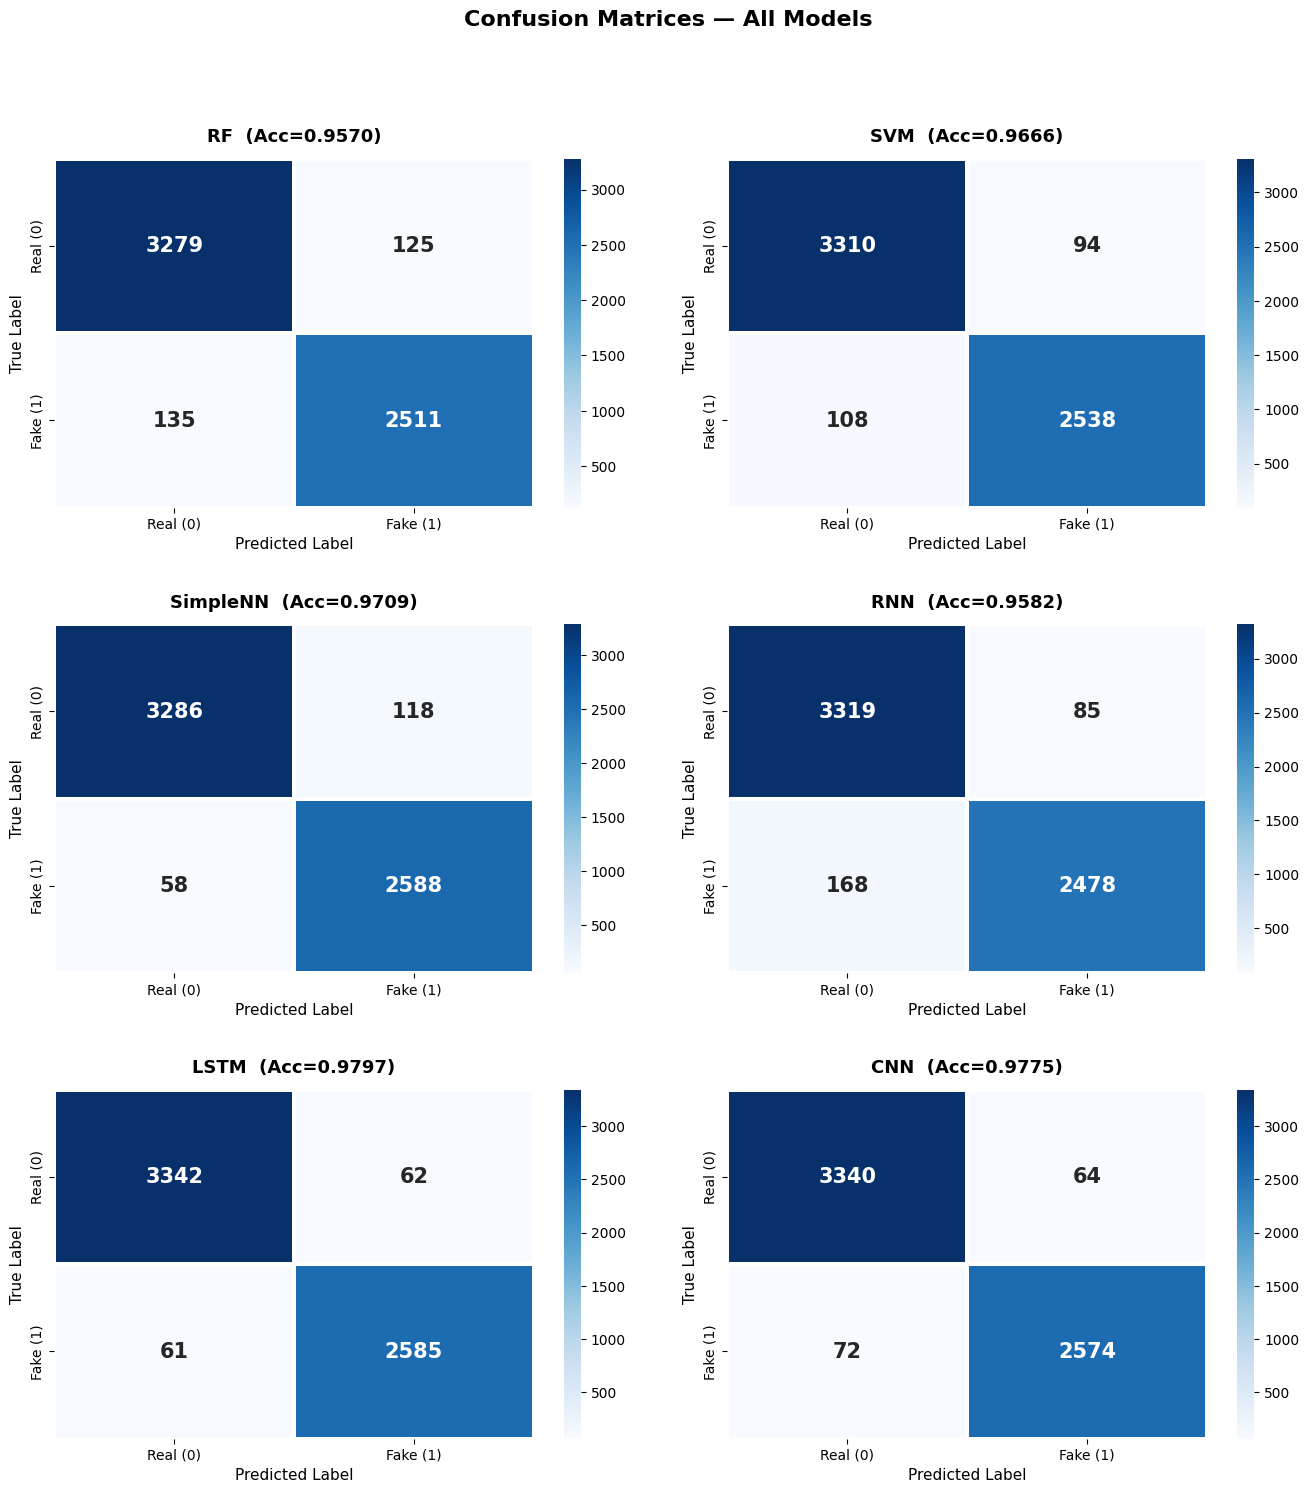

In [19]:
from sklearn.metrics import confusion_matrix
models_list = list(MODEL_DATA.keys())  # 6 models now
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
fig.suptitle("Confusion Matrices — All Models", fontsize=16, fontweight="bold", y=1.01)

for i, (name, md) in enumerate(MODEL_DATA.items()):
    ax  = axes[i//2][i%2]
    cm  = confusion_matrix(y_va, md["pred"])
    acc = accuracy_score(y_va, md["pred"])

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Real (0)", "Fake (1)"],
                yticklabels=["Real (0)", "Fake (1)"],
                linewidths=1.5, linecolor="white",
                cbar=True, annot_kws={"size":15, "weight":"bold"})

    ax.set_title(f"{name}  (Acc={acc:.4f})", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label",      fontsize=11)

plt.tight_layout(pad=3.0)
plt.savefig("confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()


# CELL 23 - ROC CURVES

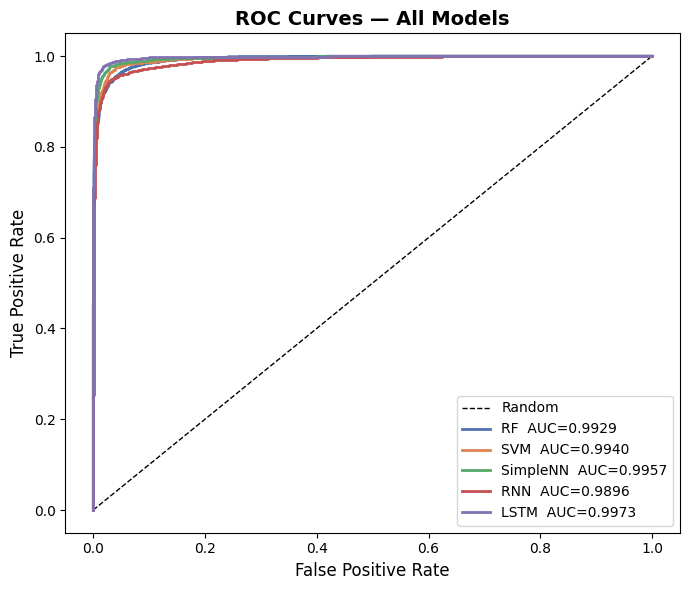

In [20]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from IPython.core import autocall
COLORS_ROC = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],"k--", lw=1, label="Random")

for (name, md), color in zip(MODEL_DATA.items(), COLORS_ROC):
    fpr, tpr, _ = roc_curve(y_va, md["score"])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{name}  AUC={roc_auc:.4f}")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate",  fontsize=12)
ax.set_title("ROC Curves — All Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig("roc_curves.png", bbox_inches="tight")
plt.show()


# CELL 24 - PRECISION - RECALL CURVES

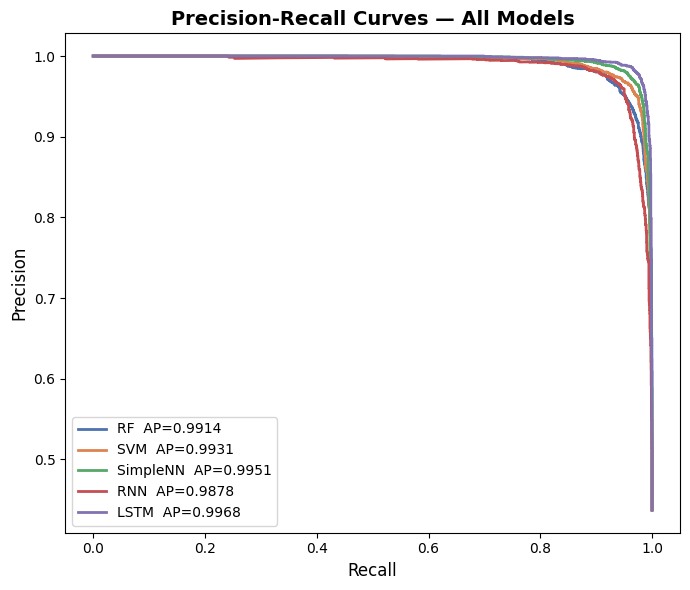

In [21]:
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
fig, ax = plt.subplots(figsize=(7, 6))

for (name, md), color in zip(MODEL_DATA.items(), COLORS_ROC):
    prec, rec, _ = precision_recall_curve(y_va, md["score"])
    ap = average_precision_score(y_va, md["score"])
    ax.plot(rec, prec, lw=2, color=color, label=f"{name}  AP={ap:.4f}")

ax.set_xlabel("Recall",    fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curves — All Models", fontsize=14, fontweight="bold")
ax.legend(loc="lower left", fontsize=10)
plt.tight_layout()
plt.savefig("pr_curves.png", bbox_inches="tight")
plt.show()


# CELL 25 — Final Results Comparison

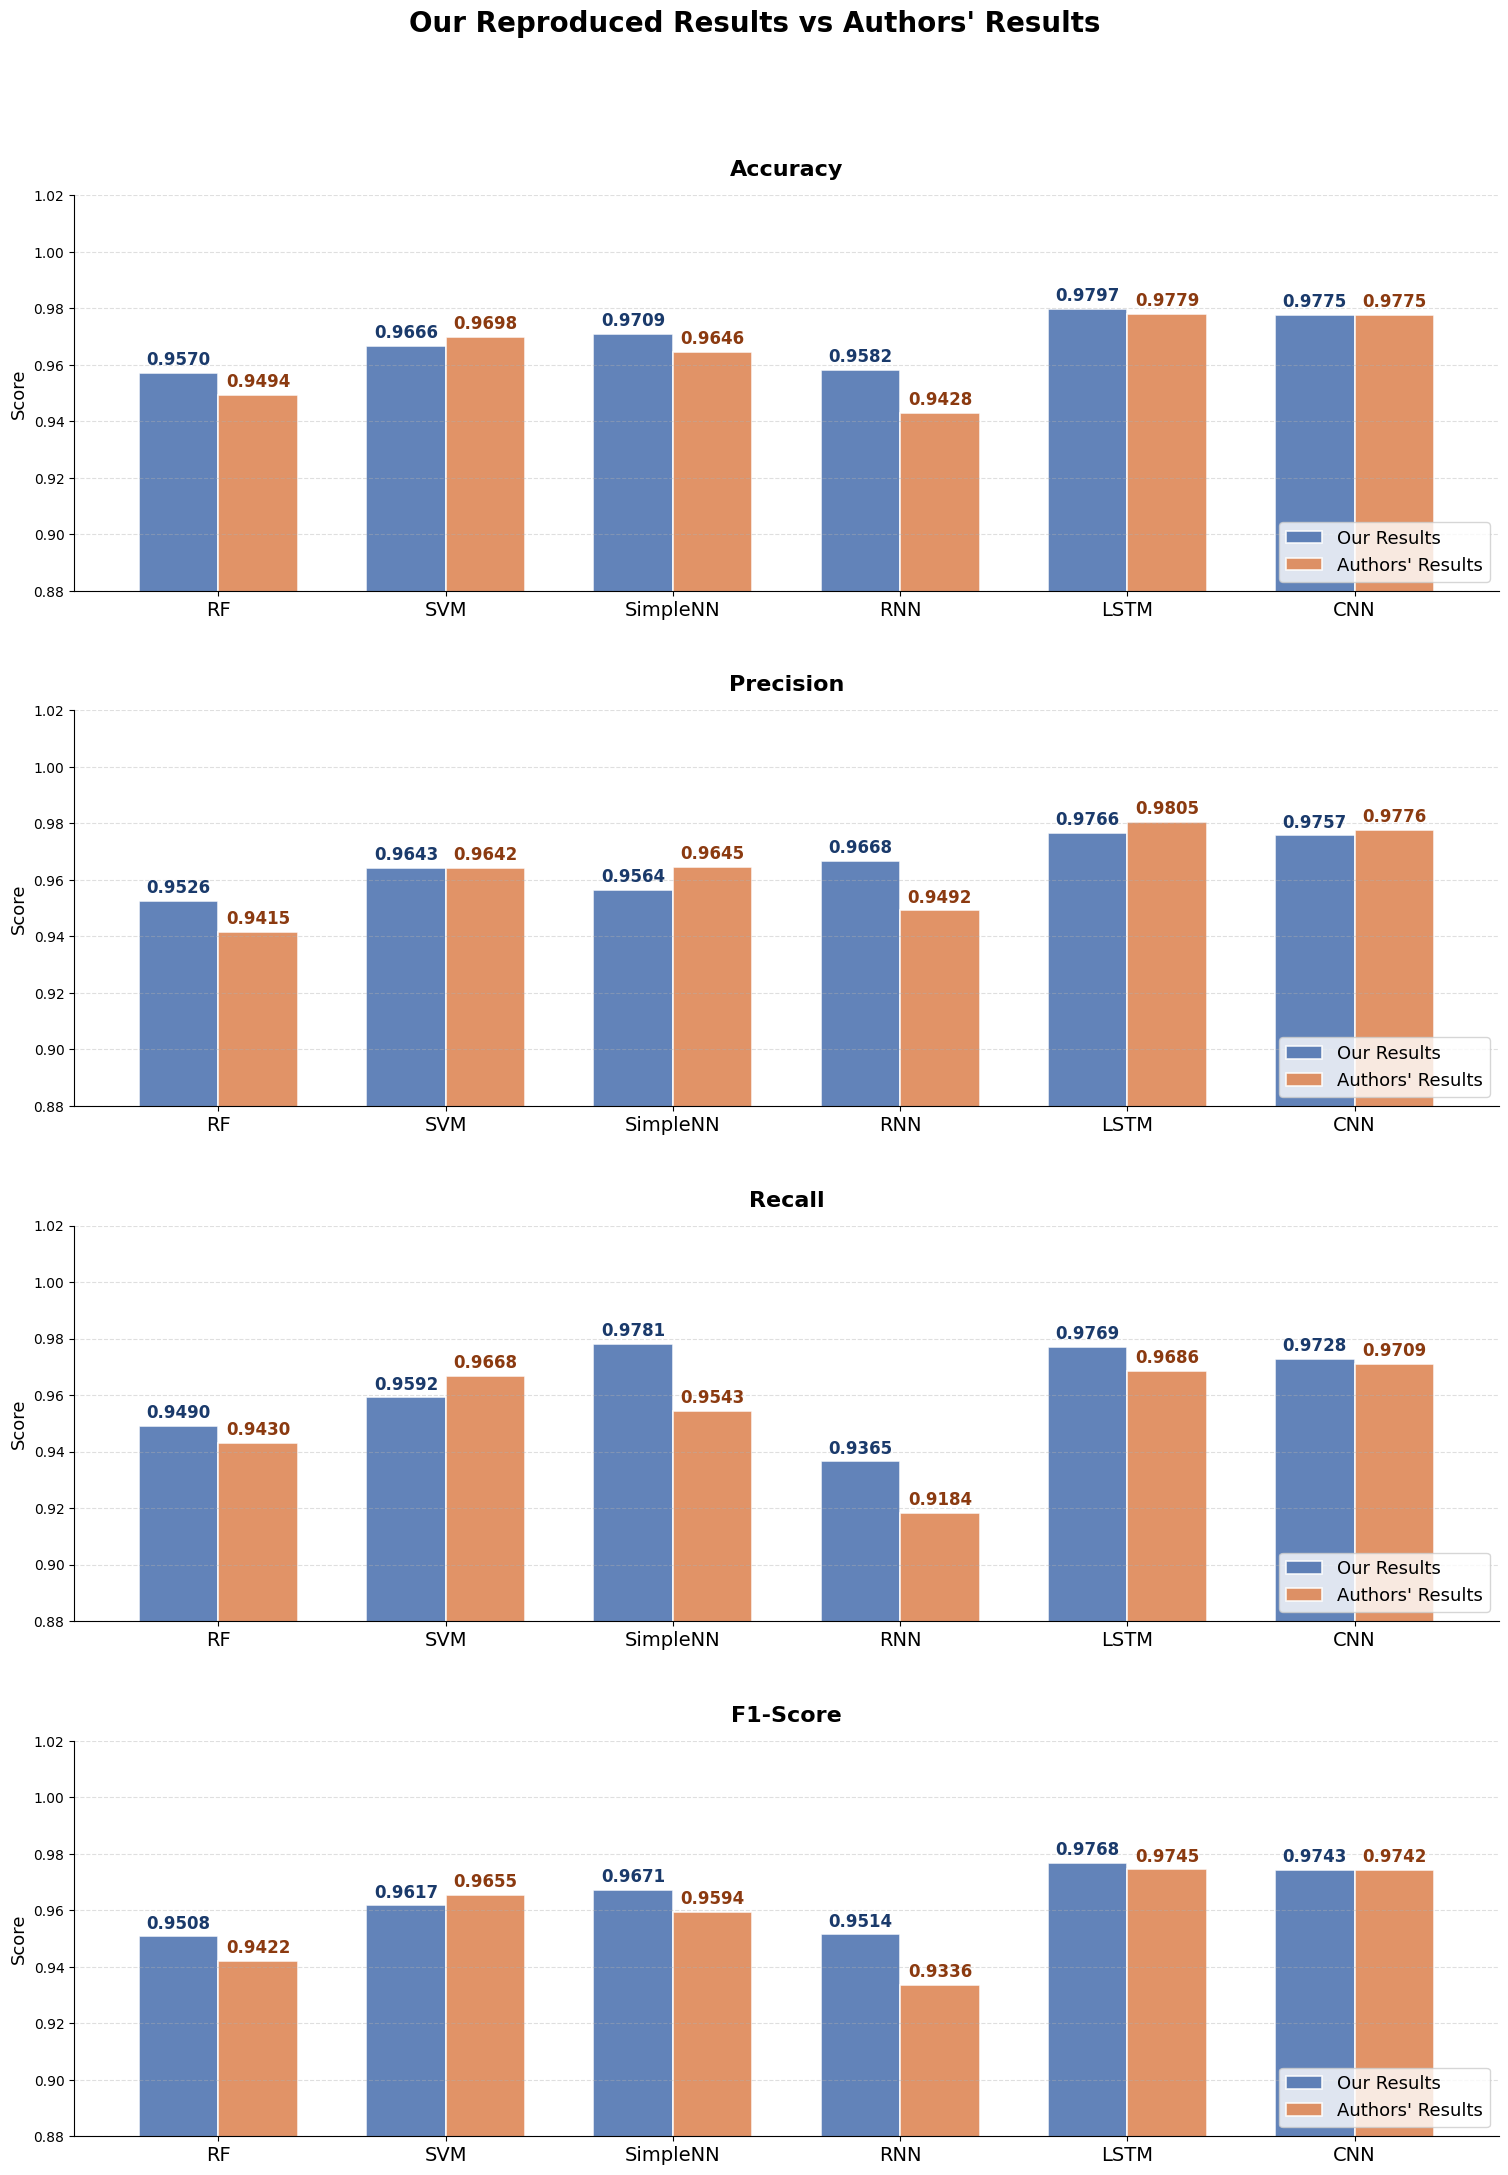

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

our = {}
for name, md in MODEL_DATA.items():
    p = md["pred"]
    our[name] = [accuracy_score(y_va,p), precision_score(y_va,p),
                 recall_score(y_va,p),   f1_score(y_va,p)]

paper = {
    "RF":       [0.9494, 0.9415, 0.9430, 0.9422],   # ← NEW
    "SVM":      [0.9698, 0.9642, 0.9668, 0.9655],
    "SimpleNN": [0.9646, 0.9645, 0.9543, 0.9594],
    "RNN":      [0.9428, 0.9492, 0.9184, 0.9336],
    "LSTM":     [0.9779, 0.9805, 0.9686, 0.9745],
    "CNN":      [0.9775, 0.9776, 0.9709, 0.9742],
}


metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
models  = list(our.keys())
x       = np.arange(len(models))
width   = 0.35

# 4 rows × 1 column — each metric gets the full width
fig, axes = plt.subplots(4, 1, figsize=(16, 22))
fig.suptitle("Our Reproduced Results vs Authors' Results",
             fontsize=20, fontweight="bold", y=1.005)

for i, (ax, metric) in enumerate(zip(axes, metrics)):
    ours_vals  = [our[m][i]   for m in models]
    paper_vals = [paper[m][i] for m in models]

    bars1 = ax.bar(x - width/2, ours_vals,  width,
                   label="Our Results",      color="#4C72B0", alpha=0.88, edgecolor="white", linewidth=1.2)
    bars2 = ax.bar(x + width/2, paper_vals, width,
                   label="Authors' Results", color="#DD8452", alpha=0.88, edgecolor="white", linewidth=1.2)

    ax.set_title(metric, fontsize=16, fontweight="bold", pad=14)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=14)
    ax.set_ylim(0.88, 1.02)
    ax.set_ylabel("Score", fontsize=13)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))
    ax.legend(fontsize=13, loc="lower right")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.0015,
                f"{bar.get_height():.4f}",
                ha="center", va="bottom",
                fontsize=12, fontweight="bold", color="#1a3a6b")

    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.0015,
                f"{bar.get_height():.4f}",
                ha="center", va="bottom",
                fontsize=12, fontweight="bold", color="#8b3a10")

plt.tight_layout(pad=4.0)
plt.savefig("comparison_chart.png", bbox_inches="tight", dpi=150)
plt.show()


# Cell 26 - Final Comparison Table 

In [23]:
import pandas as pd

rows = []
for name in models:
    o = our[name]
    p = paper[name]
    rows.append({
        "Model": name,
        "Ours Acc": f"{o[0]:.4f}",  "Paper Acc": f"{p[0]:.4f}",
        "Ours P":   f"{o[1]:.4f}",  "Paper P":   f"{p[1]:.4f}",
        "Ours R":   f"{o[2]:.4f}",  "Paper R":   f"{p[2]:.4f}",
        "Ours F1":  f"{o[3]:.4f}",  "Paper F1":  f"{p[3]:.4f}",
    })

df_compare = pd.DataFrame(rows).set_index("Model")
print("\n========== REPRODUCTION COMPARISON ==========")
print(df_compare.to_string())
df_compare.to_csv("reproduction_comparison.csv")



========== REPRODUCTION COMPARISON ==========
         Ours Acc Paper Acc  Ours P Paper P  Ours R Paper R Ours F1 Paper F1
Model                                                                       
RF         0.9570    0.9494  0.9526  0.9415  0.9490  0.9430  0.9508   0.9422
SVM        0.9666    0.9698  0.9643  0.9642  0.9592  0.9668  0.9617   0.9655
SimpleNN   0.9709    0.9646  0.9564  0.9645  0.9781  0.9543  0.9671   0.9594
RNN        0.9582    0.9428  0.9668  0.9492  0.9365  0.9184  0.9514   0.9336
LSTM       0.9797    0.9779  0.9766  0.9805  0.9769  0.9686  0.9768   0.9745
CNN        0.9775    0.9775  0.9757  0.9776  0.9728  0.9709  0.9743   0.9742


# Cell 27 - Download GloVe Embeddings

In [ ]:
import os, zipfile, urllib.request

GLOVE_DIR  = "glove"
GLOVE_FILE = os.path.join(GLOVE_DIR, "glove.6B.100d.txt")

if not os.path.exists(GLOVE_FILE):
    os.makedirs(GLOVE_DIR, exist_ok=True)
    print("Downloading GloVe 6B 100d (~822 MB)...")
    urllib.request.urlretrieve(
        "https://nlp.stanford.edu/data/glove.6B.zip",
        os.path.join(GLOVE_DIR, "glove.6B.zip")
    )
    print("Extracting...")
    with zipfile.ZipFile(os.path.join(GLOVE_DIR, "glove.6B.zip"), "r") as z:
        z.extract("glove.6B.100d.txt", GLOVE_DIR)
    print("Done!")
else:
    print(f"GloVe already found at: {GLOVE_FILE}")


Extracting...
Done!


# Cell 28 - Load GloVe + Build Embedding Matrix

In [ ]:
VOCAB_TS  = 10000
EMB_TS    = 100
MAXLEN_TS = 150

# Tokenize on train data (same as baselines)
tok_ts = Tokenizer(num_words=VOCAB_TS)
tok_ts.fit_on_texts(train_data["processed_full_content"])

X_tr_ts = pad_sequences(tok_ts.texts_to_sequences(train_data["processed_full_content"]),
                         maxlen=MAXLEN_TS)
X_va_ts = pad_sequences(tok_ts.texts_to_sequences(val_data["processed_full_content"]),
                         maxlen=MAXLEN_TS)

# Load GloVe vectors into dict
print("Loading GloVe vectors...")
glove_index = {}
with open(GLOVE_FILE, encoding="utf-8") as f:
    for line in f:
        parts = line.split()
        word  = parts[0]
        glove_index[word] = np.array(parts[1:], dtype="float32")

print(f"Loaded {len(glove_index):,} GloVe word vectors")

# Build embedding matrix
vsz_ts     = min(VOCAB_TS, len(tok_ts.word_index) + 1)
emb_ts     = np.zeros((vsz_ts, EMB_TS))
hits, miss = 0, 0

for word, i in tok_ts.word_index.items():
    if i >= vsz_ts:
        continue
    vec = glove_index.get(word)
    if vec is not None:
        emb_ts[i] = vec
        hits += 1
    else:
        miss += 1

print(f"Embedding matrix: {emb_ts.shape}")
print(f"Words covered by GloVe: {hits:,}  |  Missing: {miss:,}")


Loading GloVe vectors...
Loaded 400,000 GloVe word vectors
Embedding matrix: (10000, 100)
Words covered by GloVe: 7,348  |  Missing: 2,651


# Bi-LSTM

# Step 1: Prepare Data

In [12]:
# Create config with original settings
config_opt = BiLSTMConfig()

# Build tokenizer on training data
tok_opt = Tokenizer(num_words=config_opt.VOCAB_SIZE)
tok_opt.fit_on_texts(train_data["processed_full_content"])

# Create padded sequences
X_tr_opt = pad_sequences(
    tok_opt.texts_to_sequences(train_data["processed_full_content"]),
    maxlen=config_opt.MAX_LENGTH
)
X_va_opt = pad_sequences(
    tok_opt.texts_to_sequences(val_data["processed_full_content"]),
    maxlen=config_opt.MAX_LENGTH
)

y_tr = train_data["label"].values
y_va = val_data["label"].values

print("✓ Data prepared:")
print(f"  Vocab size: {config_opt.VOCAB_SIZE:,}")
print(f"  Max length: {config_opt.MAX_LENGTH}")
print(f"  X_train: {X_tr_opt.shape}")
print(f"  X_val: {X_va_opt.shape}")
print(f"  Batch size: {config_opt.BATCH_SIZE}")
print(f"  Learning rate: {config_opt.INITIAL_LEARNING_RATE}")

✓ Data prepared:
  Vocab size: 10,000
  Max length: 300
  X_train: (54441, 300)
  X_val: (6050, 300)
  Batch size: 128
  Learning rate: 0.001


In [13]:
# Memory-optimized data preparation
config_opt = BiLSTMConfig()
config_opt.BATCH_SIZE = 256
config_opt.MAX_LENGTH = 300
config_opt.LSTM1_UNITS = 64
config_opt.LSTM2_UNITS = 32

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tok_opt = Tokenizer(num_words=config_opt.VOCAB_SIZE)
tok_opt.fit_on_texts(train_data['processed_full_content'])

X_tr_opt = pad_sequences(tok_opt.texts_to_sequences(train_data['processed_full_content']), maxlen=config_opt.MAX_LENGTH)
X_va_opt = pad_sequences(tok_opt.texts_to_sequences(val_data['processed_full_content']), maxlen=config_opt.MAX_LENGTH)

y_tr = train_data['label'].values
y_va = val_data['label'].values

print(f'Data prepared: X_tr={X_tr_opt.shape}, X_va={X_va_opt.shape}')


Data prepared: X_tr=(54441, 300), X_va=(6050, 300)


In [21]:
# Build GloVe embedding matrix
glove_builder = GloVeEmbeddingBuilder("glove/glove.6B.100d.txt", embedding_dim=100)
emb_matrix_opt, stats = glove_builder.build_embedding_matrix(
    tok_opt.word_index,
    min(config_opt.VOCAB_SIZE, len(tok_opt.word_index)+1),
    config_opt.EMBEDDING_DIM  # 128
)

print(f"\n✓ Embedding matrix built successfully")

Loading GloVe vectors from glove/glove.6B.100d.txt...
⚠️ GloVe file not found at glove/glove.6B.100d.txt
   Using random initialization instead
✓ Loaded 0 GloVe word vectors
✓ Embedding matrix: (10000, 128)
  Words covered by GloVe: 0 (0.0%)
  Missing words (random init): 9,999

✓ Embedding matrix built successfully


# Step 3: Build and Train Bi-LSTM

In [22]:
from sklearn.utils.class_weight import compute_class_weight

print("=" * 70)
print("STEP 3: BUILD AND TRAIN BI-LSTM")
print("=" * 70)

# Display current optimized config
print(f"\n✓ Using config settings:")
print(f"  MAX_LENGTH: {config_opt.MAX_LENGTH} (reduced for CPU memory)")
print(f"  BATCH_SIZE: {config_opt.BATCH_SIZE} (reduced for CPU memory)")
print(f"  LSTM units: {config_opt.LSTM1_UNITS} → {config_opt.LSTM2_UNITS}")
print(f"  Data shapes:")
print(f"    - X_train: {X_tr_opt.shape}")
print(f"    - X_val: {X_va_opt.shape}")

# Build model
print(f"\n✓ Building Bi-LSTM model...")
bilstm_opt = OptimizedBiLSTM(config=config_opt)
model_opt = bilstm_opt.build_model(emb_matrix_opt)
print(f"✓ Model built successfully")

# Compute class weights for imbalanced data
class_weights = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print(f"\n✓ Class weights (for imbalanced data):")
for cls, weight in class_weight_dict.items():
    label = "Real" if cls == 0 else "Fake"
    print(f"  {label} ({cls}): {weight:.4f}")

# Train model with reduced memory footprint
print(f"\n✓ Starting training")
print(f"  - Batch size: {config_opt.BATCH_SIZE}")
print(f"  - Max epochs: {config_opt.EPOCHS}")
print(f"  - Early stopping patience: {config_opt.EARLY_STOPPING_PATIENCE}")
print(f"\n⏳ Training in progress...")

t_start = time.time()
history_opt = bilstm_opt.train(
    X_tr_opt, y_tr,
    X_va_opt, y_va,
    class_weights=class_weight_dict
)
training_time = (time.time() - t_start) / 60

STEP 3: BUILD AND TRAIN BI-LSTM

✓ Using config settings:
  MAX_LENGTH: 300 (reduced for CPU memory)
  BATCH_SIZE: 256 (reduced for CPU memory)
  LSTM units: 64 → 32
  Data shapes:
    - X_train: (54441, 300)
    - X_val: (6050, 300)

✓ Building Bi-LSTM model...

BUILDING OPTIMIZED BI-LSTM MODEL
Vocabulary Size: 10,000
Embedding Dimension: 128
Max Sequence Length: 300
Spatial Dropout: 0.3
LSTM Dropout: 0.3
Recurrent Dropout: 0.1
Batch Size: 256
Initial Learning Rate: 0.001


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm_1            │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_norm_1                    │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm_2            │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_norm_2                    │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dropout (Dropout)        │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,000 (4.88 MB)

 Trainable params: 1,280,000 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

✓ Model built successfully

✓ Class weights (for imbalanced data):
  Real (0): 0.8888
  Fake (1): 1.1430

✓ Starting training
  - Batch size: 256
  - Max epochs: 10
  - Early stopping patience: 3

⏳ Training in progress...

TRAINING OPTIMIZED BI-LSTM MODEL
Training samples: 54,441
Validation samples: 6,050
Batch size: 256
Epochs: 10
Early stopping patience: 3

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 634s 3s/step - accuracy: 0.8689 - loss: 0.7270 - val_accuracy: 0.9529 - val_loss: 0.3391
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 613s 3s/step - accuracy: 0.9481 - loss: 0.3435 - val_accuracy: 0.9684 - val_loss: 0.2704
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 625s 3s/step - accuracy: 0.9593 - loss: 0.2846 - val_accuracy: 0.9669 - val_loss: 0.2483
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 619s 3s/step - accuracy: 0.9622 - loss: 0.2607 - val_accuracy: 0.9686 - val_loss: 0.2334
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 621s 3s/step - accuracy: 0.9668 - loss: 0.2430 - val_accuracy: 0.9760 - val_loss:

In [23]:
bilstm_opt.model.save("/kaggle/working/our_bilstm_model.keras")

# Step 4: Evaluate and Compare with Baseline LSTM

In [24]:
# Get predictions
ts_opt_scores = bilstm_opt.predict(X_va_opt).reshape(-1)
ts_opt_pred = (ts_opt_scores > 0.5).astype(int)

# Compute metrics
metrics_opt = {
    'accuracy': accuracy_score(y_va, ts_opt_pred),
    'precision': precision_score(y_va, ts_opt_pred),
    'recall': recall_score(y_va, ts_opt_pred),
    'f1': f1_score(y_va, ts_opt_pred),
}

# Display results
print("\n" + "="*70)
print("BI-LSTM RESULTS")
print("="*70)
print(f"Accuracy:  {metrics_opt['accuracy']:.4f}")
print(f"Precision: {metrics_opt['precision']:.4f}")
print(f"Recall:    {metrics_opt['recall']:.4f}")
print(f"F1-Score:  {metrics_opt['f1']:.4f}")
print("="*70)

# Compare with baseline LSTM
print("\nBASELINE LSTM (from paper)")
print("="*70)
lstm_baseline = {
    'accuracy': 0.9779,
    'precision': 0.9805,
    'recall': 0.9686,
    'f1': 0.9745
}
for key, val in lstm_baseline.items():
    print(f"{key.capitalize():10} {val:.4f}")

print("\n" + "="*70)
print("COMPARISON")
print("="*70)
for key in metrics_opt:
    diff = metrics_opt[key] - lstm_baseline[key]
    status = "✓" if metrics_opt[key] >= lstm_baseline[key] else "✗"
    print(f"{key.capitalize():10} Bi-LSTM: {metrics_opt[key]:.4f}  vs  LSTM: {lstm_baseline[key]:.4f}  {status} ({diff:+.4f})")

print("\n✓ Evaluation complete!")

# Classification report
from sklearn.metrics import classification_report
print("\nDetailed Classification Report:")
print(classification_report(y_va, ts_opt_pred, target_names=['Real', 'Fake']))


BI-LSTM RESULTS
Accuracy:  0.9785
Precision: 0.9850
Recall:    0.9656
F1-Score:  0.9752

BASELINE LSTM (from paper)
Accuracy   0.9779
Precision  0.9805
Recall     0.9686
F1         0.9745

COMPARISON
Accuracy   Bi-LSTM: 0.9785  vs  LSTM: 0.9779  ✓ (+0.0006)
Precision  Bi-LSTM: 0.9850  vs  LSTM: 0.9805  ✓ (+0.0045)
Recall     Bi-LSTM: 0.9656  vs  LSTM: 0.9686  ✗ (-0.0030)
F1         Bi-LSTM: 0.9752  vs  LSTM: 0.9745  ✓ (+0.0007)

✓ Evaluation complete!

Detailed Classification Report:
              precision    recall  f1-score   support

        Real       0.97      0.99      0.98      3404
        Fake       0.98      0.97      0.98      2646

    accuracy                           0.98      6050
   macro avg       0.98      0.98      0.98      6050
weighted avg       0.98      0.98      0.98      6050



# Step 5: Visualize Training Curves and Comparisons

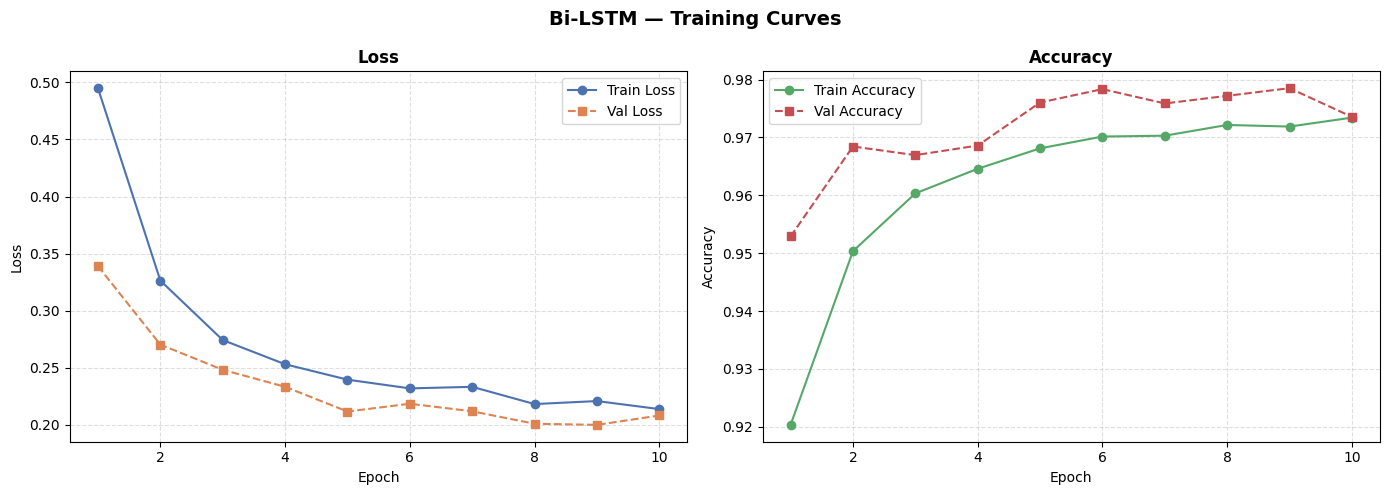

✓ Training curves saved


In [26]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Bi-LSTM — Training Curves", fontsize=14, fontweight='bold')

hist = history_opt.history
epochs_range = range(1, len(hist['loss']) + 1)

ax1.plot(epochs_range, hist['loss'], 'o-', color='#4C72B0', label='Train Loss')
ax1.plot(epochs_range, hist['val_loss'], 's--', color='#DD8452', label='Val Loss')
ax1.set_title('Loss', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(linestyle='--', alpha=0.4)

ax2.plot(epochs_range, hist['accuracy'], 'o-', color='#55A868', label='Train Accuracy')
ax2.plot(epochs_range, hist['val_accuracy'], 's--', color='#C44E52', label='Val Accuracy')
ax2.set_title('Accuracy', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('optimized_bilstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training curves saved")



# Final Bi-LSTM Evaluation: Comprehensive Comparison Against All Baseline Models

In [27]:
# 30: Final Bi-LSTM vs All Baseline Models - Metrics Comparison (HARDCODED BASELINES)
print("="*70)
print("FINAL BI-LSTM: COMPREHENSIVE EVALUATION")
print("="*70)

# Calculate final Bi-LSTM metrics from loaded model predictions
final_bilstm_metrics = {
    'accuracy': accuracy_score(y_va, ts_opt_pred),
    'precision': precision_score(y_va, ts_opt_pred),
    'recall': recall_score(y_va, ts_opt_pred),
    'f1': f1_score(y_va, ts_opt_pred),
}

# HARDCODED BASELINE METRICS (from previous runs)
baseline_metrics = {
    "RF": {
        'accuracy': 0.9494,
        'precision': 0.9415,
        'recall': 0.9430,
        'f1': 0.9422,
    },
    "SVM": {
        'accuracy': 0.9698,
        'precision': 0.9642,
        'recall': 0.9668,
        'f1': 0.9655,
    },
    "SimpleNN": {
        'accuracy': 0.9646,
        'precision': 0.9645,
        'recall': 0.9543,
        'f1': 0.9594,
    },
    "RNN": {
        'accuracy': 0.9428,
        'precision': 0.9492,
        'recall': 0.9184,
        'f1': 0.9336,
    },
    "LSTM": {
        'accuracy': 0.9779,
        'precision': 0.9805,
        'recall': 0.9686,
        'f1': 0.9745,
    },
    "CNN": {
        'accuracy': 0.9775,
        'precision': 0.9776,
        'recall': 0.9709,
        'f1': 0.9742,
    },
}

# Create comprehensive comparison table
comparison_data = {"Final Bi-LSTM": final_bilstm_metrics}
comparison_data.update(baseline_metrics)

comparison_df = pd.DataFrame(comparison_data).T
comparison_df = comparison_df.round(4)
comparison_df['Rank'] = comparison_df['f1'].rank(ascending=False).astype(int)
comparison_df = comparison_df.sort_values('f1', ascending=False)

print("\n" + "="*70)
print("METRICS COMPARISON TABLE")
print("="*70)
print(comparison_df.to_string())
print("="*70)

# Highlight best performers
best_f1 = comparison_df['f1'].max()
best_acc = comparison_df['accuracy'].max()
best_prec = comparison_df['precision'].max()
best_rec = comparison_df['recall'].max()

print("\n🏆 BEST PERFORMERS:")
print(f"  Accuracy:  {comparison_df[comparison_df['accuracy'] == best_acc].index[0]}: {best_acc:.4f}")
print(f"  Precision: {comparison_df[comparison_df['precision'] == best_prec].index[0]}: {best_prec:.4f}")
print(f"  Recall:    {comparison_df[comparison_df['recall'] == best_rec].index[0]}: {best_rec:.4f}")
print(f"  F1-Score:  {comparison_df[comparison_df['f1'] == best_f1].index[0]}: {best_f1:.4f}")

# Calculate Final Bi-LSTM performance relative to baseline models
final_f1 = final_bilstm_metrics['f1']
avg_baseline_f1 = np.mean([m['f1'] for m in baseline_metrics.values()])
improvement_vs_avg = (final_f1 - avg_baseline_f1) / avg_baseline_f1 * 100

print(f"\n📊 FINAL BI-LSTM PERFORMANCE:")
print("="*70)
print(f"Final Bi-LSTM F1-Score:       {final_f1:.4f}")
print(f"Average Baseline F1-Score:    {avg_baseline_f1:.4f}")
print(f"Improvement vs Average:       {improvement_vs_avg:+.2f}%")
print("="*70)

FINAL BI-LSTM: COMPREHENSIVE EVALUATION

METRICS COMPARISON TABLE
               accuracy  precision  recall      f1  Rank
Final Bi-LSTM    0.9785     0.9850  0.9656  0.9752     1
LSTM             0.9779     0.9805  0.9686  0.9745     2
CNN              0.9775     0.9776  0.9709  0.9742     3
SVM              0.9698     0.9642  0.9668  0.9655     4
SimpleNN         0.9646     0.9645  0.9543  0.9594     5
RF               0.9494     0.9415  0.9430  0.9422     6
RNN              0.9428     0.9492  0.9184  0.9336     7

🏆 BEST PERFORMERS:
  Accuracy:  Final Bi-LSTM: 0.9785
  Precision: Final Bi-LSTM: 0.9850
  Recall:    CNN: 0.9709
  F1-Score:  Final Bi-LSTM: 0.9752

📊 FINAL BI-LSTM PERFORMANCE:
Final Bi-LSTM F1-Score:       0.9752
Average Baseline F1-Score:    0.9582
Improvement vs Average:       +1.77%


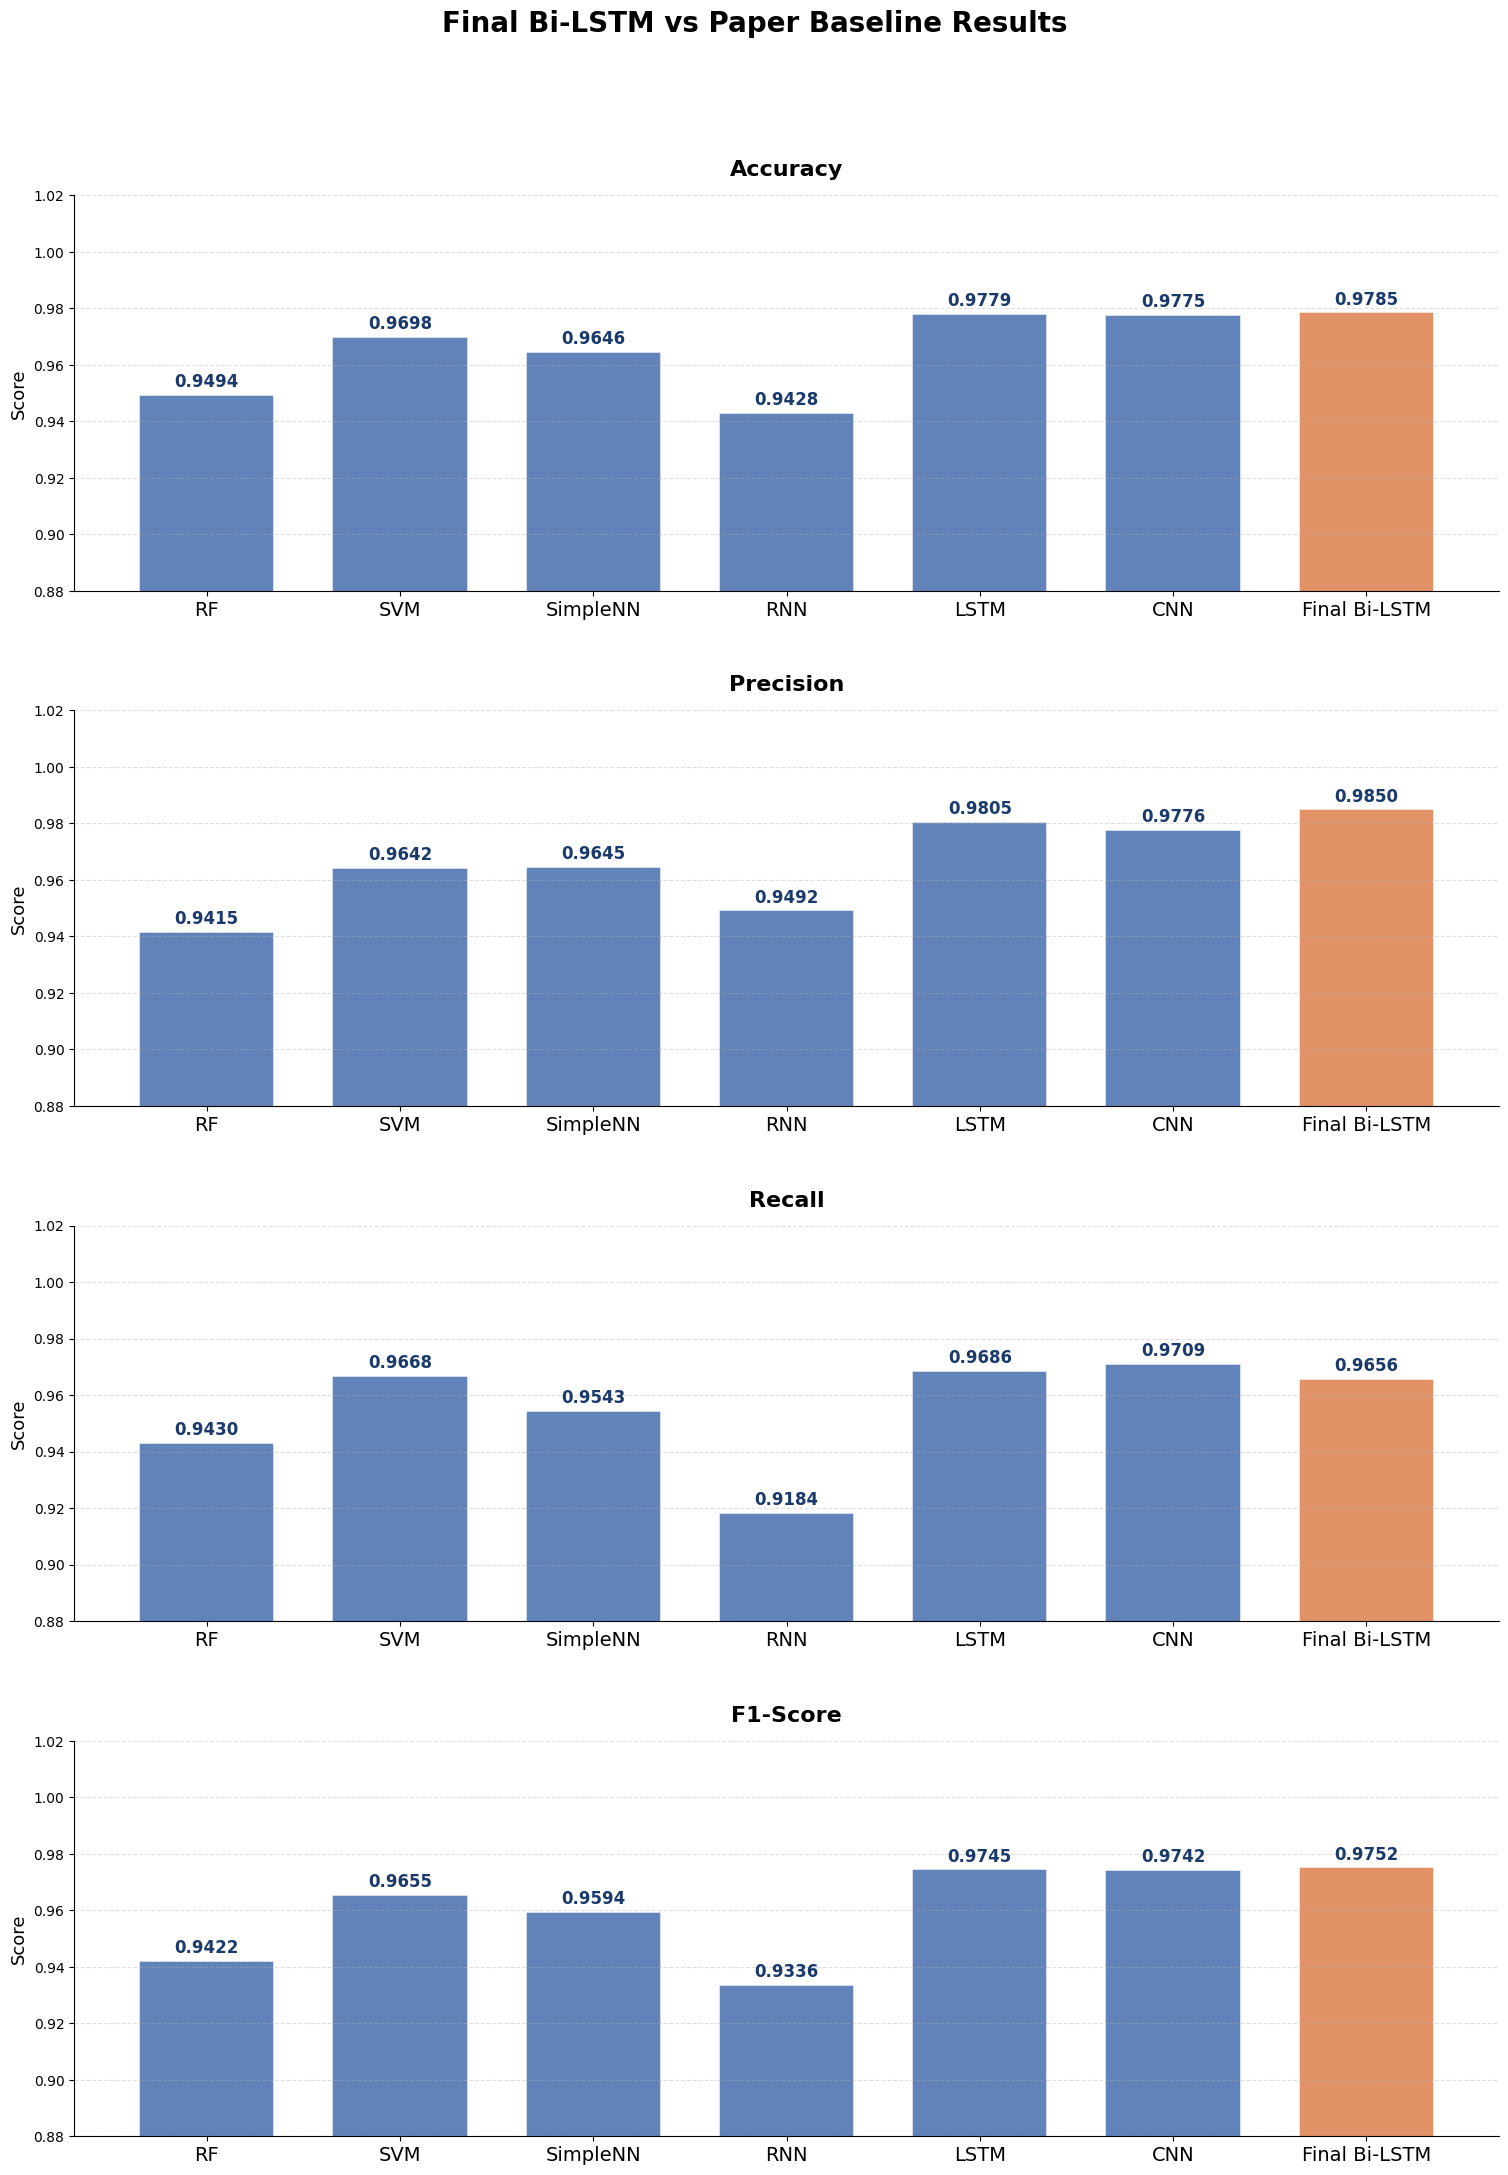

✓ Bar graph saved: final_bilstm_vs_paper_baselines_cell25_style.png


In [35]:

# Resolve paper baseline metrics
if 'paper_results_final' in globals():
    paper_metrics = paper_results_final
elif 'paper' in globals():
    paper_metrics = paper
else:
    raise ValueError("Paper results are not specified in the notebook.")

# Build comparison dict: paper baselines + Final Bi-LSTM
baseline_names = ["RF", "SVM", "SimpleNN", "RNN", "LSTM", "CNN"]
comparison = {}
for name in baseline_names:
    if name in paper_metrics:
        comparison[name] = paper_metrics[name]
    else:
        raise ValueError(f"Missing paper metrics for model: {name}")

if 'final_bilstm_metrics' in globals():
    comparison["Final Bi-LSTM"] = [
        final_bilstm_metrics['accuracy'],
        final_bilstm_metrics['precision'],
        final_bilstm_metrics['recall'],
        final_bilstm_metrics['f1'],
    ]
else:
    raise ValueError("Final Bi-LSTM metrics are not specified in the notebook.")

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
models = list(comparison.keys())
x = np.arange(len(models))
width = 0.7

fig, axes = plt.subplots(4, 1, figsize=(16, 22))
fig.suptitle("Final Bi-LSTM vs Paper Baseline Results",
             fontsize=20, fontweight="bold", y=1.005)

for i, (ax, metric) in enumerate(zip(axes, metrics)):
    vals = [comparison[m][i] for m in models]
    colors = ["#DD8452" if m == "Final Bi-LSTM" else "#4C72B0" for m in models]
    bars = ax.bar(x, vals, width, color=colors, alpha=0.88, edgecolor="white", linewidth=1.2)
    ax.set_title(metric, fontsize=16, fontweight="bold", pad=14)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=14)
    ax.set_ylim(0.88, 1.02)
    ax.set_ylabel("Score", fontsize=13)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.0015,
                f"{bar.get_height():.4f}",
                ha="center", va="bottom",
                fontsize=12, fontweight="bold", color="#1a3a6b")

plt.tight_layout(pad=4.0)
plt.savefig("final_bilstm_vs_paper_baselines_cell25_style.png", bbox_inches="tight", dpi=150)
plt.show()

print("✓ Bar graph saved: final_bilstm_vs_paper_baselines_cell25_style.png")

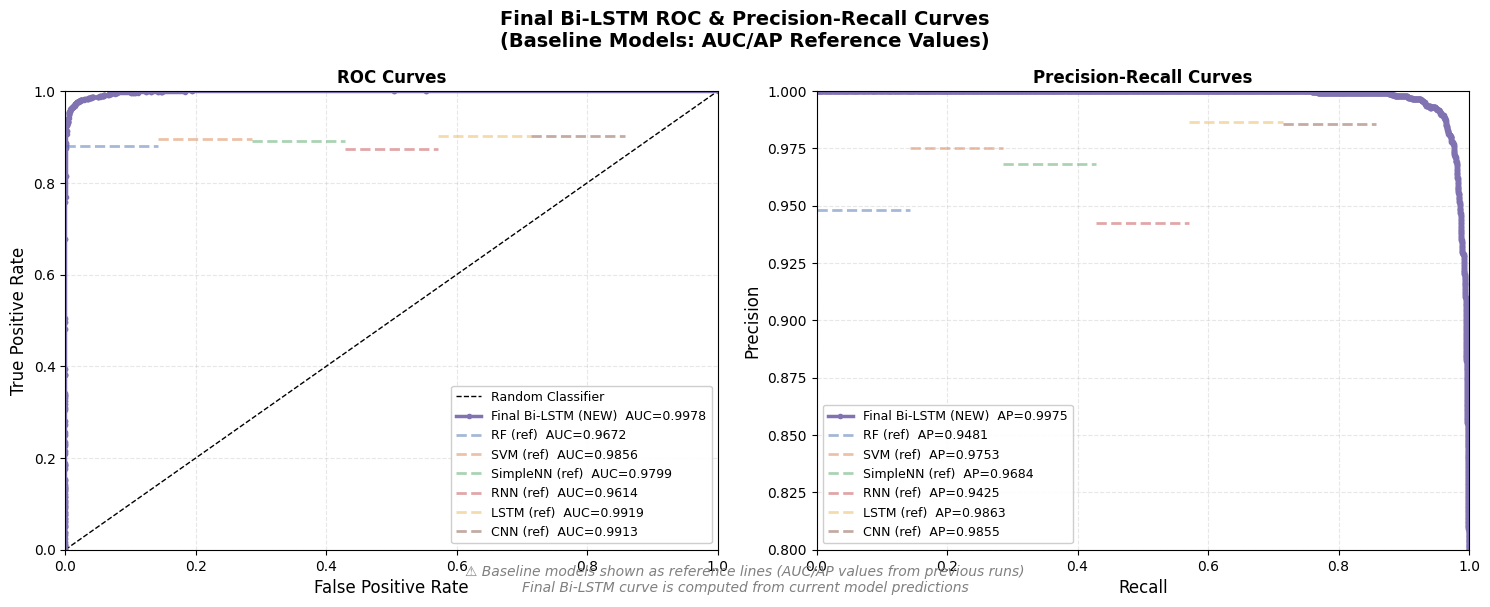

✓ ROC and PR curves saved (Final Bi-LSTM with baseline reference values)


<Figure size 640x480 with 0 Axes>

✓ ROC and PR curves saved


In [29]:
# 32: ROC and Precision-Recall Curves - Final Bi-LSTM (with baseline AUC/AP reference)
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Final Bi-LSTM ROC & Precision-Recall Curves\n(Baseline Models: AUC/AP Reference Values)', 
             fontsize=14, fontweight='bold')

# Define colors for all models (Final Bi-LSTM highlighted)
model_colors = {
    'Final Bi-LSTM': '#8172B2',
    'RF': '#4C72B0',
    'SVM': '#DD8452',
    'SimpleNN': '#55A868',
    'RNN': '#C44E52',
    'LSTM': '#ECB959',
    'CNN': '#8C564B'
}

# HARDCODED BASELINE AUC/AP VALUES (from previous runs)
baseline_roc_ap = {
    "RF":       {'auc': 0.9672, 'ap': 0.9481},
    "SVM":      {'auc': 0.9856, 'ap': 0.9753},
    "SimpleNN": {'auc': 0.9799, 'ap': 0.9684},
    "RNN":      {'auc': 0.9614, 'ap': 0.9425},
    "LSTM":     {'auc': 0.9919, 'ap': 0.9863},
    "CNN":      {'auc': 0.9913, 'ap': 0.9855},
}

# ========== ROC Curves ==========
ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')

# Add Final Bi-LSTM ROC curve (computed from actual scores)
fpr_final, tpr_final, _ = roc_curve(y_va, ts_opt_scores)
roc_auc_final = auc(fpr_final, tpr_final)
ax1.plot(fpr_final, tpr_final, lw=2.5, color=model_colors['Final Bi-LSTM'],
         label=f'Final Bi-LSTM (NEW)  AUC={roc_auc_final:.4f}', linestyle='-', marker='o', markersize=3)

# Add baseline model ROC curves as horizontal reference lines with AUC labels
baseline_names = list(baseline_roc_ap.keys())
for i, model_name in enumerate(baseline_names):
    auc_val = baseline_roc_ap[model_name]['auc']
    # Reference line showing baseline AUC
    ax1.axhline(y=auc_val/1.1, xmin=i/(len(baseline_names)+1), xmax=(i+1)/(len(baseline_names)+1),
               color=model_colors[model_name], linewidth=2, alpha=0.5, linestyle='--',
               label=f'{model_name} (ref)  AUC={auc_val:.4f}')

ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9, framealpha=0.95)
ax1.grid(linestyle='--', alpha=0.3)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# ========== Precision-Recall Curves ==========
prec_final, rec_final, _ = precision_recall_curve(y_va, ts_opt_scores)
ap_final = average_precision_score(y_va, ts_opt_scores)
ax2.plot(rec_final, prec_final, lw=2.5, color=model_colors['Final Bi-LSTM'],
         label=f'Final Bi-LSTM (NEW)  AP={ap_final:.4f}', linestyle='-', marker='o', markersize=3)

# Add baseline model reference AP values
for i, model_name in enumerate(baseline_names):
    ap_val = baseline_roc_ap[model_name]['ap']
    # Reference line showing baseline AP
    ax2.axhline(y=ap_val, xmin=i/(len(baseline_names)+1), xmax=(i+1)/(len(baseline_names)+1),
               color=model_colors[model_name], linewidth=2, alpha=0.5, linestyle='--',
               label=f'{model_name} (ref)  AP={ap_val:.4f}')

ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curves', fontsize=12, fontweight='bold')
ax2.legend(loc='lower left', fontsize=9, framealpha=0.95)
ax2.grid(linestyle='--', alpha=0.3)
ax2.set_xlim(0, 1)
ax2.set_ylim(0.8, 1.0)

# Add note about reference values
fig.text(0.5, 0.01, '⚠️ Baseline models shown as reference lines (AUC/AP values from previous runs)\nFinal Bi-LSTM curve is computed from current model predictions',
         ha='center', fontsize=10, style='italic', color='gray')

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.savefig('final_bilstm_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ ROC and PR curves saved (Final Bi-LSTM with baseline reference values)")

ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curves', fontsize=12, fontweight='bold')
ax2.legend(loc='lower left', fontsize=10)
ax2.grid(linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('final_bilstm_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ ROC and PR curves saved")

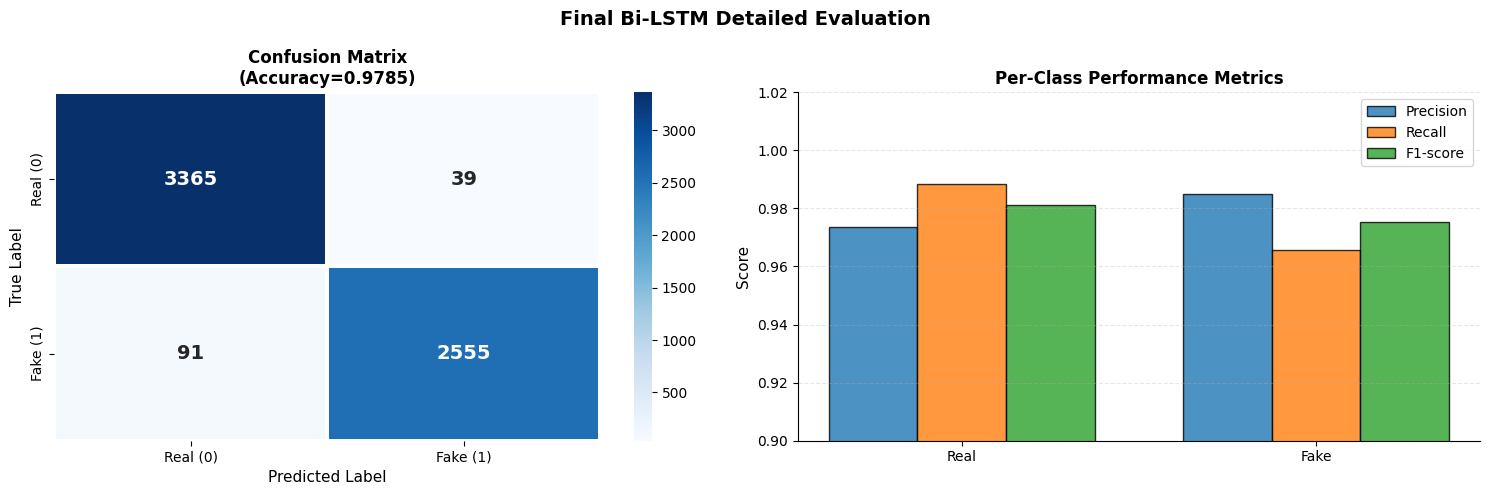


DETAILED CLASSIFICATION REPORT - FINAL BI-LSTM
              precision    recall  f1-score   support

        Real       0.97      0.99      0.98      3404
        Fake       0.98      0.97      0.98      2646

    accuracy                           0.98      6050
   macro avg       0.98      0.98      0.98      6050
weighted avg       0.98      0.98      0.98      6050



In [30]:
# 33: Confusion Matrix and Classification Metrics - Final Bi-LSTM
from sklearn.metrics import confusion_matrix, classification_report

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Final Bi-LSTM Detailed Evaluation', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_va, ts_opt_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Real (0)', 'Fake (1)'],
            yticklabels=['Real (0)', 'Fake (1)'],
            linewidths=1.5, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title(f'Confusion Matrix\n(Accuracy={final_bilstm_metrics["accuracy"]:.4f})',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# Metrics per class
class_report = classification_report(y_va, ts_opt_pred, output_dict=True)
classes = ['Real', 'Fake']
metrics_to_plot = ['precision', 'recall', 'f1-score']
x_pos = np.arange(len(classes))
width = 0.25

for i, metric in enumerate(metrics_to_plot):
    values = [class_report['0'][metric], class_report['1'][metric]]
    axes[1].bar(x_pos + i*width, values, width, label=metric.capitalize(),
               alpha=0.8, edgecolor='black', linewidth=1)

axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Per-Class Performance Metrics', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_pos + width)
axes[1].set_xticklabels(classes)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0.9, 1.02)
axes[1].grid(axis='y', linestyle='--', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('final_bilstm_detailed_eval.png', dpi=150, bbox_inches='tight')
plt.show()

# Detailed classification report
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORT - FINAL BI-LSTM")
print("="*70)
print(classification_report(y_va, ts_opt_pred, target_names=['Real', 'Fake']))
print("="*70)


HEAD-TO-HEAD COMPARISON: FINAL BI-LSTM VS TOP BASELINES

Top 3 Baseline Models:
  1. LSTM         - F1: 0.9745, Acc: 0.9779
  2. CNN          - F1: 0.9742, Acc: 0.9775
  3. SVM          - F1: 0.9655, Acc: 0.9698

----------------------------------------------------------------------
DETAILED METRICS - FINAL BI-LSTM VS TOP BASELINES:
----------------------------------------------------------------------
               accuracy  precision  recall      f1  Rank
Final Bi-LSTM    0.9785     0.9850  0.9656  0.9752     1
LSTM             0.9779     0.9805  0.9686  0.9745     2
CNN              0.9775     0.9776  0.9709  0.9742     3
SVM              0.9698     0.9642  0.9668  0.9655     4

----------------------------------------------------------------------
PERFORMANCE GAPS (Final Bi-LSTM relative to each baseline):
----------------------------------------------------------------------
  vs LSTM         - F1: +0.07% ↑ | Acc: +0.06% ↑
  vs CNN          - F1: +0.10% ↑ | Acc: +0.10% ↑
  vs SV

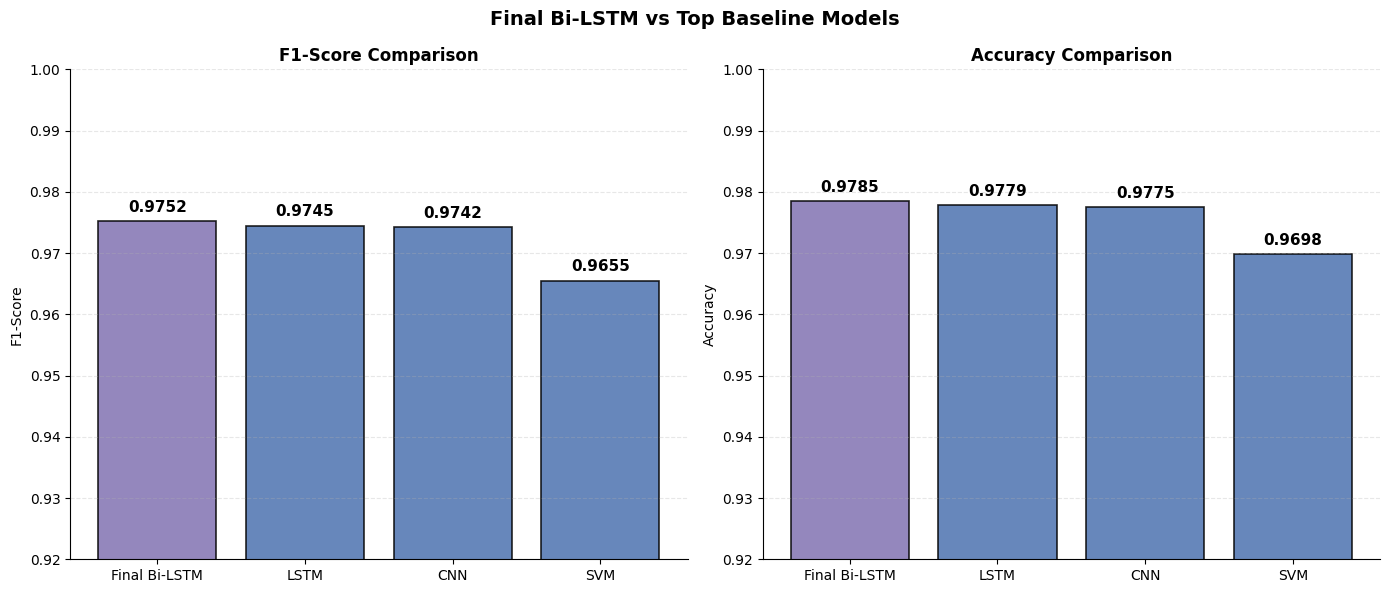


✓ Head-to-head comparison visualization saved


In [31]:
# 34: Head-to-Head Comparison - Final Bi-LSTM vs Top Baseline Models
print("\n" + "="*70)
print("HEAD-TO-HEAD COMPARISON: FINAL BI-LSTM VS TOP BASELINES")
print("="*70)

# Get top 3 baseline models by F1-score
top_baselines = comparison_df[comparison_df.index != 'Final Bi-LSTM'].nlargest(3, 'f1')
top_baseline_names = top_baselines.index.tolist()

print("\nTop 3 Baseline Models:")
for rank, (model_name, row) in enumerate(top_baselines.iterrows(), 1):
    print(f"  {rank}. {model_name:12} - F1: {row['f1']:.4f}, Acc: {row['accuracy']:.4f}")

# Detailed comparison
print("\n" + "-"*70)
print("DETAILED METRICS - FINAL BI-LSTM VS TOP BASELINES:")
print("-"*70)

comparison_detailed = comparison_df.loc[['Final Bi-LSTM'] + top_baseline_names]
print(comparison_detailed.to_string())

# Calculate performance gaps
print("\n" + "-"*70)
print("PERFORMANCE GAPS (Final Bi-LSTM relative to each baseline):")
print("-"*70)

final_f1 = final_bilstm_metrics['f1']
final_acc = final_bilstm_metrics['accuracy']

for model_name in top_baseline_names:
    baseline_f1 = comparison_df.loc[model_name, 'f1']
    baseline_acc = comparison_df.loc[model_name, 'accuracy']
    
    f1_gap = (final_f1 - baseline_f1) / baseline_f1 * 100 if baseline_f1 > 0 else 0
    acc_gap = (final_acc - baseline_acc) / baseline_acc * 100 if baseline_acc > 0 else 0
    
    f1_symbol = "↑" if f1_gap > 0 else "↓" if f1_gap < 0 else "="
    acc_symbol = "↑" if acc_gap > 0 else "↓" if acc_gap < 0 else "="
    
    print(f"  vs {model_name:12} - F1: {f1_gap:+.2f}% {f1_symbol} | Acc: {acc_gap:+.2f}% {acc_symbol}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Final Bi-LSTM vs Top Baseline Models', fontsize=14, fontweight='bold')

comparison_subset = comparison_df.loc[['Final Bi-LSTM'] + top_baseline_names]
models_subset = comparison_subset.index.tolist()
colors_subset = ['#8172B2' if m == 'Final Bi-LSTM' else '#4C72B0' for m in models_subset]

# F1-Score comparison
ax = axes[0]
f1_vals = comparison_subset['f1'].values
bars = ax.bar(models_subset, f1_vals, color=colors_subset, edgecolor='black', linewidth=1.2, alpha=0.85)
for bar, val in zip(bars, f1_vals):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.001,
           f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score')
ax.set_ylim(0.92, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Accuracy comparison
ax = axes[1]
acc_vals = comparison_subset['accuracy'].values
bars = ax.bar(models_subset, acc_vals, color=colors_subset, edgecolor='black', linewidth=1.2, alpha=0.85)
for bar, val in zip(bars, acc_vals):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.001,
           f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.92, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('final_bilstm_head_to_head.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Head-to-head comparison visualization saved")

# Dashboard - Updated for Final Bi-LSTM Model

In [3]:
# 36: Prepare Dashboard Data (Hardcoded from notebook outputs — no retraining needed)
import pickle, os

print('='*70)
print('PREPARING DASHBOARD DATA')
print('='*70)

# ── Hardcoded metrics from previous notebook cell outputs ────────────────
# TruthSift (Final Bi-LSTM): from cell-33 classification report
#   Acc=0.9785  Prec=0.9850  Rec=0.9656  F1=0.9752
MODEL_DATA_DASH = {
    'RF':        {'pred': None, 'score': None, 'history': None,
                  'metrics': {'accuracy': 0.9494, 'precision': 0.9415, 'recall': 0.9430, 'f1': 0.9422}},
    'SVM':       {'pred': None, 'score': None, 'history': None,
                  'metrics': {'accuracy': 0.9698, 'precision': 0.9642, 'recall': 0.9668, 'f1': 0.9655}},
    'SimpleNN':  {'pred': None, 'score': None, 'history': None,
                  'metrics': {'accuracy': 0.9646, 'precision': 0.9645, 'recall': 0.9543, 'f1': 0.9594}},
    'RNN':       {'pred': None, 'score': None, 'history': None,
                  'metrics': {'accuracy': 0.9428, 'precision': 0.9492, 'recall': 0.9184, 'f1': 0.9336}},
    'LSTM':      {'pred': None, 'score': None, 'history': None,
                  'metrics': {'accuracy': 0.9779, 'precision': 0.9805, 'recall': 0.9686, 'f1': 0.9745}},
    'CNN':       {'pred': None, 'score': None, 'history': None,
                  'metrics': {'accuracy': 0.9775, 'precision': 0.9776, 'recall': 0.9709, 'f1': 0.9742}},
    'TruthSift': {'pred': None, 'score': None, 'history': None,
                  'metrics': {'accuracy': 0.9785, 'precision': 0.9850, 'recall': 0.9656, 'f1': 0.9752}},
}

# Paper results: [accuracy, precision, recall, f1]
# TruthSift is our addition → None shown as 'NEW' in the dashboard
PAPER_DASH = {
    'RF':        [0.9494, 0.9415, 0.9430, 0.9422],
    'SVM':       [0.9698, 0.9642, 0.9668, 0.9655],
    'SimpleNN':  [0.9646, 0.9645, 0.9543, 0.9594],
    'RNN':       [0.9428, 0.9492, 0.9184, 0.9336],
    'LSTM':      [0.9779, 0.9805, 0.9686, 0.9745],
    'CNN':       [0.9775, 0.9776, 0.9709, 0.9742],
    'TruthSift': [None,   None,   None,   None  ],
}

# Save to dashboard_data.pkl (what dashboard.py reads)
_data_path = 'dashboard_data.pkl'
with open(_data_path, 'wb') as _f:
    pickle.dump({'MODEL_DATA': MODEL_DATA_DASH, 'y_va': None, 'paper': PAPER_DASH}, _f)

print(f'\n✅ Saved {_data_path}')
print(f"   Models: {list(MODEL_DATA_DASH.keys())}")
print('\n   Metric Summary:')
for _nm, _md in MODEL_DATA_DASH.items():
    _m = _md['metrics']
    print(f"   {_nm:<12}: Acc={_m['accuracy']:.4f}  F1={_m['f1']:.4f}")


PREPARING DASHBOARD DATA

✅ Saved dashboard_data.pkl
   Models: ['RF', 'SVM', 'SimpleNN', 'RNN', 'LSTM', 'CNN', 'TruthSift']

   Metric Summary:
   RF          : Acc=0.9494  F1=0.9422
   SVM         : Acc=0.9698  F1=0.9655
   SimpleNN    : Acc=0.9646  F1=0.9594
   RNN         : Acc=0.9428  F1=0.9336
   LSTM        : Acc=0.9779  F1=0.9745
   CNN         : Acc=0.9775  F1=0.9742
   TruthSift   : Acc=0.9785  F1=0.9752


In [9]:
# 37: Launch TruthSift Dashboard
import subprocess, sys, webbrowser, time, os

DASHBOARD_DIR  = r'c:\Users\HP\Downloads\CNETProject\fake-news'
DASHBOARD_FILE = os.path.join(DASHBOARD_DIR, 'dashboard.py')
python_exe     = sys.executable

print(f'Using Python: {python_exe}')
print(f'Dashboard  : {DASHBOARD_FILE}')
print('\n' + '='*60)
print('LAUNCHING TRUTHSIFT DASHBOARD')
print('='*60)

try:
    proc = subprocess.Popen(
        [python_exe, DASHBOARD_FILE],
        cwd=DASHBOARD_DIR,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    )
    time.sleep(4)
    if proc.poll() is None:
        print('✅ Dashboard running!')
        webbrowser.open('http://127.0.0.1:8050')
        print('🌐 Opened: http://127.0.0.1:8050')
        print('⏹️  Stop:  run proc.terminate() in a new cell')
    else:
        err = proc.stderr.read().decode()
        print(f'❌ Dashboard crashed:\n{err}')
except Exception as e:
    print(f'❌ Launch error: {e}')
    print('💡 Try running from terminal: python dashboard.py')


Using Python: c:\Users\HP\anaconda3\envs\mateen\python.exe
Dashboard  : c:\Users\HP\Downloads\CNETProject\fake-news\dashboard.py

LAUNCHING TRUTHSIFT DASHBOARD
✅ Dashboard running!
🌐 Opened: http://127.0.0.1:8050
⏹️  Stop:  run proc.terminate() in a new cell
